In [1]:
setwd("/well/lindgren-ukbb/projects/ukbb-11867/flassen/projects/KO/wes_ko_ukbb")
devtools::load_all("utils/modules/R/gwastools")
devtools::load_all("utils/modules/R/prstools")
library(data.table)
library(ggrastr)

i Loading gwastools

Loading required package: data.table

Loading required package: ggplot2

Loading required package: stringr

! Adding files missing in collate: /gpfs3/well/lindgren-ukbb/projects/ukbb-11867/flassen/projects/KO/wes_ko_ukbb/utils/modules/R/gwastools/R/get_ldsc_param.R, /gpfs3/well/lindgren-ukbb/projects/ukbb-11867/flassen/projects/KO/wes_ko_ukbb/utils/modules/R/gwastools/R/get_saige_dir.R, /gpfs3/well/lindgren-ukbb/projects/ukbb-11867/flassen/projects/KO/wes_ko_ukbb/utils/modules/R/gwastools/R/misc.R, and /gpfs3/well/lindgren-ukbb/projects/ukbb-11867/flassen/projects/KO/wes_ko_ukbb/utils/modules/R/gwastools/R/which_overlap.R

i Loading PRStools

Loading required package: bigsnpr

Loading required package: bigstatsr

Loading required package: bigassertr

! Skipping missing files: /gpfs3/well/lindgren-ukbb/projects/ukbb-11867/flassen/projects/KO/wes_ko_ukbb/utils/modules/R/prstools/R/which_overlap.R



In [2]:
# get simulated paramters used
get_sim_params <- function(f){
    return(
        list(
            b = gsub("(_b_)|(_pi)","",stringr::str_extract(basename(f), "_b.+pi")),
            pi = gsub("(pi_)|(_K)","",stringr::str_extract(basename(f), "pi.+K")),
            h2 = gsub("(h2_)|(_b)","",stringr::str_extract(basename(f), "h2.+b")),
            k = gsub("(K)|(_seed)","",stringr::str_extract(basename(f), "K.+seed")),
            seed = gsub("(seed)|(_chr)","",stringr::str_extract(basename(f), "seed.+chr")),
            chr = stringr::str_extract(f, "chr[0-9]+"),
            case = gsub("case_", "",stringr::str_extract(f, "case_[0-9]+"))
        )
    )
}

# get path to phenotype simulations based on the saige path (step2)
get_sim_df_path <- function(f, dir="data/simulation/phenotypes_new", 
                            prefix="ukb_wes_union_calls", 
                            type="entries", suffix=".tsv.gz"){
    stopifnot(dir.exists(dir))
    params <- get_sim_params(f)
    fname <- paste0(
        prefix, 
        "_h2_", params$h2,
        "_b_", params$b,
        "_pi_", params$pi,
        "_K", params$k,
        "_seed", params$seed,
        "_", params$chr,
        "_", params$case,
        "_", type,
        suffix
    )
    fpath <- file.path(dir, fname)
    stopifnot(file.exists(fpath))
    return(fpath)
}

# get expected/observed P-values
get_qq_df <- function(f, ribbon_p = 0.95){
    stopifnot(file.exists(f))
    params <- get_sim_params(f)
    d <- fread(f)
    if (nrow(d) > 0){
        d <- d[order(d$p.value),]
        d$p.value.expt <- get_expected_p(d$p.value, na.rm = TRUE)
        n <- length(d$p.value)
        dt <- data.table(
            ensembl_gene_id = d$MarkerID, # [order(d$p.value)],
            pvalue = d$p.value,
            pvalue.observed = -log10(d$p.value),
            pvalue.expected = -log10(d$p.value.expt),
            clower = -log10(qbeta(p = (1 - ribbon_p) / 2, shape2 = n:1, shape1 = 1:n)),
            cupper = -log10(qbeta(p = (1 + ribbon_p) / 2, shape2 = n:1, shape1 = 1:n)),
            # simulation parameters
            b = as.numeric(params$b),
            pi = as.numeric(params$pi),
            h2 = as.numeric(params$h2),
            k = as.numeric(params$k),
            seed = as.numeric(params$seed),
            id = as.factor(params$case),
            # saige parameters
            AC_allele2 = as.numeric(d$AC_Allele2),
            N_case_hom = as.numeric(d$N_case_hom),
            N_ctrl_hom = as.numeric(d$N_ctrl_hom),
            fname = basename(f)
        )
        return(dt)
    }
}

get_expt_p_and_ribbon <- function(p, ribbon_p=0.95){
        p.value <- p[order(p)]
        p.value.expt <- get_expected_p(p, na.rm = TRUE)
        n <- length(p.value)
        return(
            data.table(
                pvalue = p.value,
                pvalue.observed = -log10(p.value),
                pvalue.expected = -log10(p.value.expt),
                clower = -log10(qbeta(p = (1 - ribbon_p) / 2, shape2 = n:1, shape1 = 1:n)),
                cupper = -log10(qbeta(p = (1 + ribbon_p) / 2, shape2 = n:1, shape1 = 1:n))
            )
        )
    
}

In [3]:
pattern <- "seed40"
files <- list.files("data/simulation/saige/step2/binary", pattern = pattern, full.names = TRUE)
files <- files[!grepl("index", files)]
#files <- files[grepl("var_0.", files)] #files[grepl("var_99.0", files)] #files[grepl("var_0.10", files)] #
#files <- head(files, n = 2)
#files <- files[grepl(files, pattern = "h2_0.00_")]
length(files)

[1] 250

In [4]:
lst <- list()
for (f in files){
    
    write(f, stderr())
    # get saige file and simulated pheno file
    qq_df <- get_qq_df(f)
    sim_path <- get_sim_df_path(f)
    sim_cmd <- paste("zcat", sim_path, "| grep -v NA")
    sim_df <- suppressMessages(fread(sim_cmd))
    colnames(sim_df)[colnames(sim_df) == "rsid"] <- "ensembl_gene_id"
    
    # get markers that an effect
    markers_with_effect <- sim_df[,c('ensembl_gene_id','theta')]
    markers_with_effect <- markers_with_effect[markers_with_effect$theta != 0]
    markers_with_effect <- markers_with_effect[!duplicated(markers_with_effect),]
    tmp_df <- merge(qq_df, markers_with_effect, by = "ensembl_gene_id", all.x = TRUE)
    tmp_df$theta[is.na(tmp_df$theta)] <- 0

    # get cases per marker
    markers_with_cases <- sim_df[,c('ensembl_gene_id','case')]
    markers_with_cases <- markers_with_cases[markers_with_cases$case == TRUE,]
    markers_with_cases <- aggregate(case~ensembl_gene_id, data=markers_with_cases, FUN=sum)
    tmp_df <- merge(tmp_df, markers_with_cases, by = "ensembl_gene_id", all.x = TRUE)
    tmp_df$case[is.na(tmp_df$case)] <- 0
    
    lst[[f]] <- tmp_df
}

# merge
final_df <- rbindlist(lst)

In [5]:
length(unique(final_df$ensembl_gene_id))

[1] 32

In [6]:
0.05 / (32*10*4)

[1] 3.90625e-05

In [112]:
final_df$N <- final_df$case
final_df$label_b <- paste0("b=",final_df$b)
final_df$label_h2 <- paste0("h2=",final_df$h2)

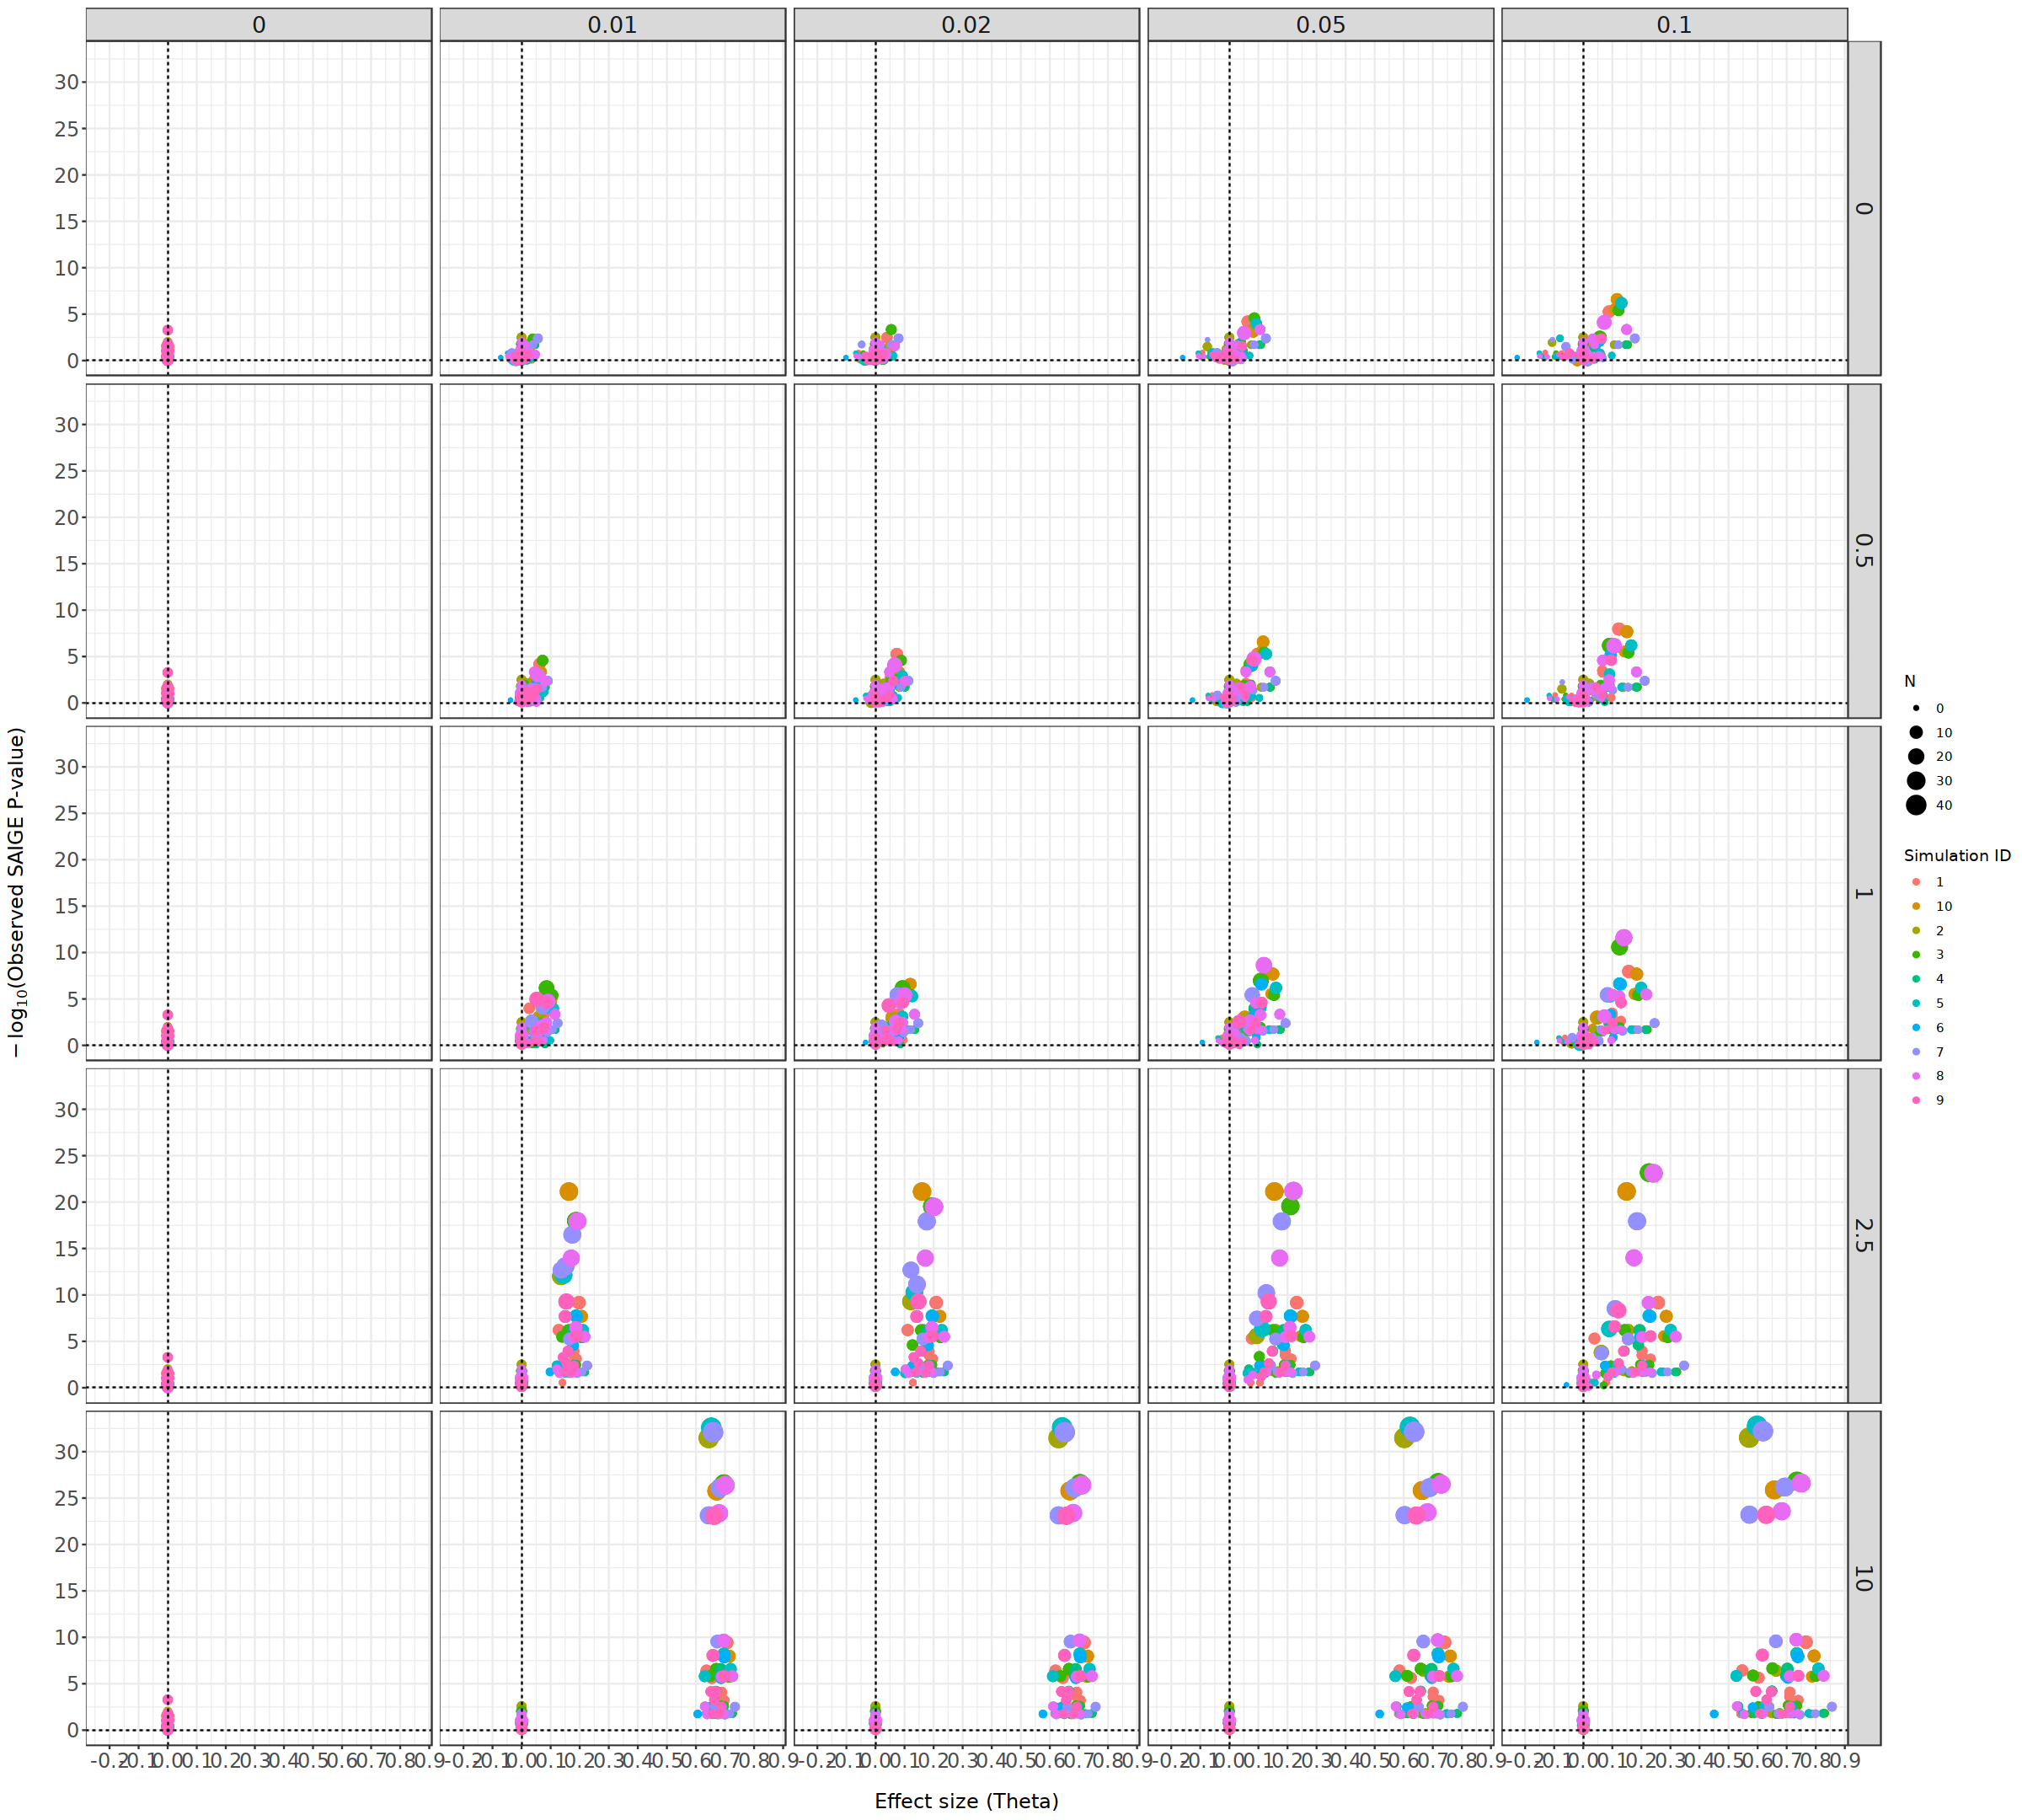

In [110]:
options(repr.plot.width=20, repr.plot.height=18)
ggplot(final_df, aes(x=theta, y=pvalue.observed, size = N, color=factor(id))) +
    geom_point_rast() +
    theme_bw() +
    geom_vline(xintercept = 0, linetype = 'dashed') +
    geom_hline(yintercept = 0, linetype = 'dashed') +
    scale_x_continuous(breaks=scales::pretty_breaks(n=10)) +
    scale_y_continuous(breaks=scales::pretty_breaks(n=10)) +
    ylab(expression(paste(-log[10],'(Observed SAIGE P-value)' ))) +
    xlab("Effect size (Theta)") +
    labs(color = "Simulation ID") +
    #facet_wrap(b~h2, scales="free_y") +
    facet_grid(b~h2) +
    theme(
        axis.text=element_text(size=14),
        axis.title=element_text(size=14),
        axis.title.x = element_text(margin=ggplot2::margin(t=16)),
        axis.title.y = element_text(margin=ggplot2::margin(r=16)),
        plot.title = element_text(hjust=0.5),
        plot.subtitle = element_text(hjust=0.5),
        strip.text = element_text(size=16),
        legend.position="right"
    )

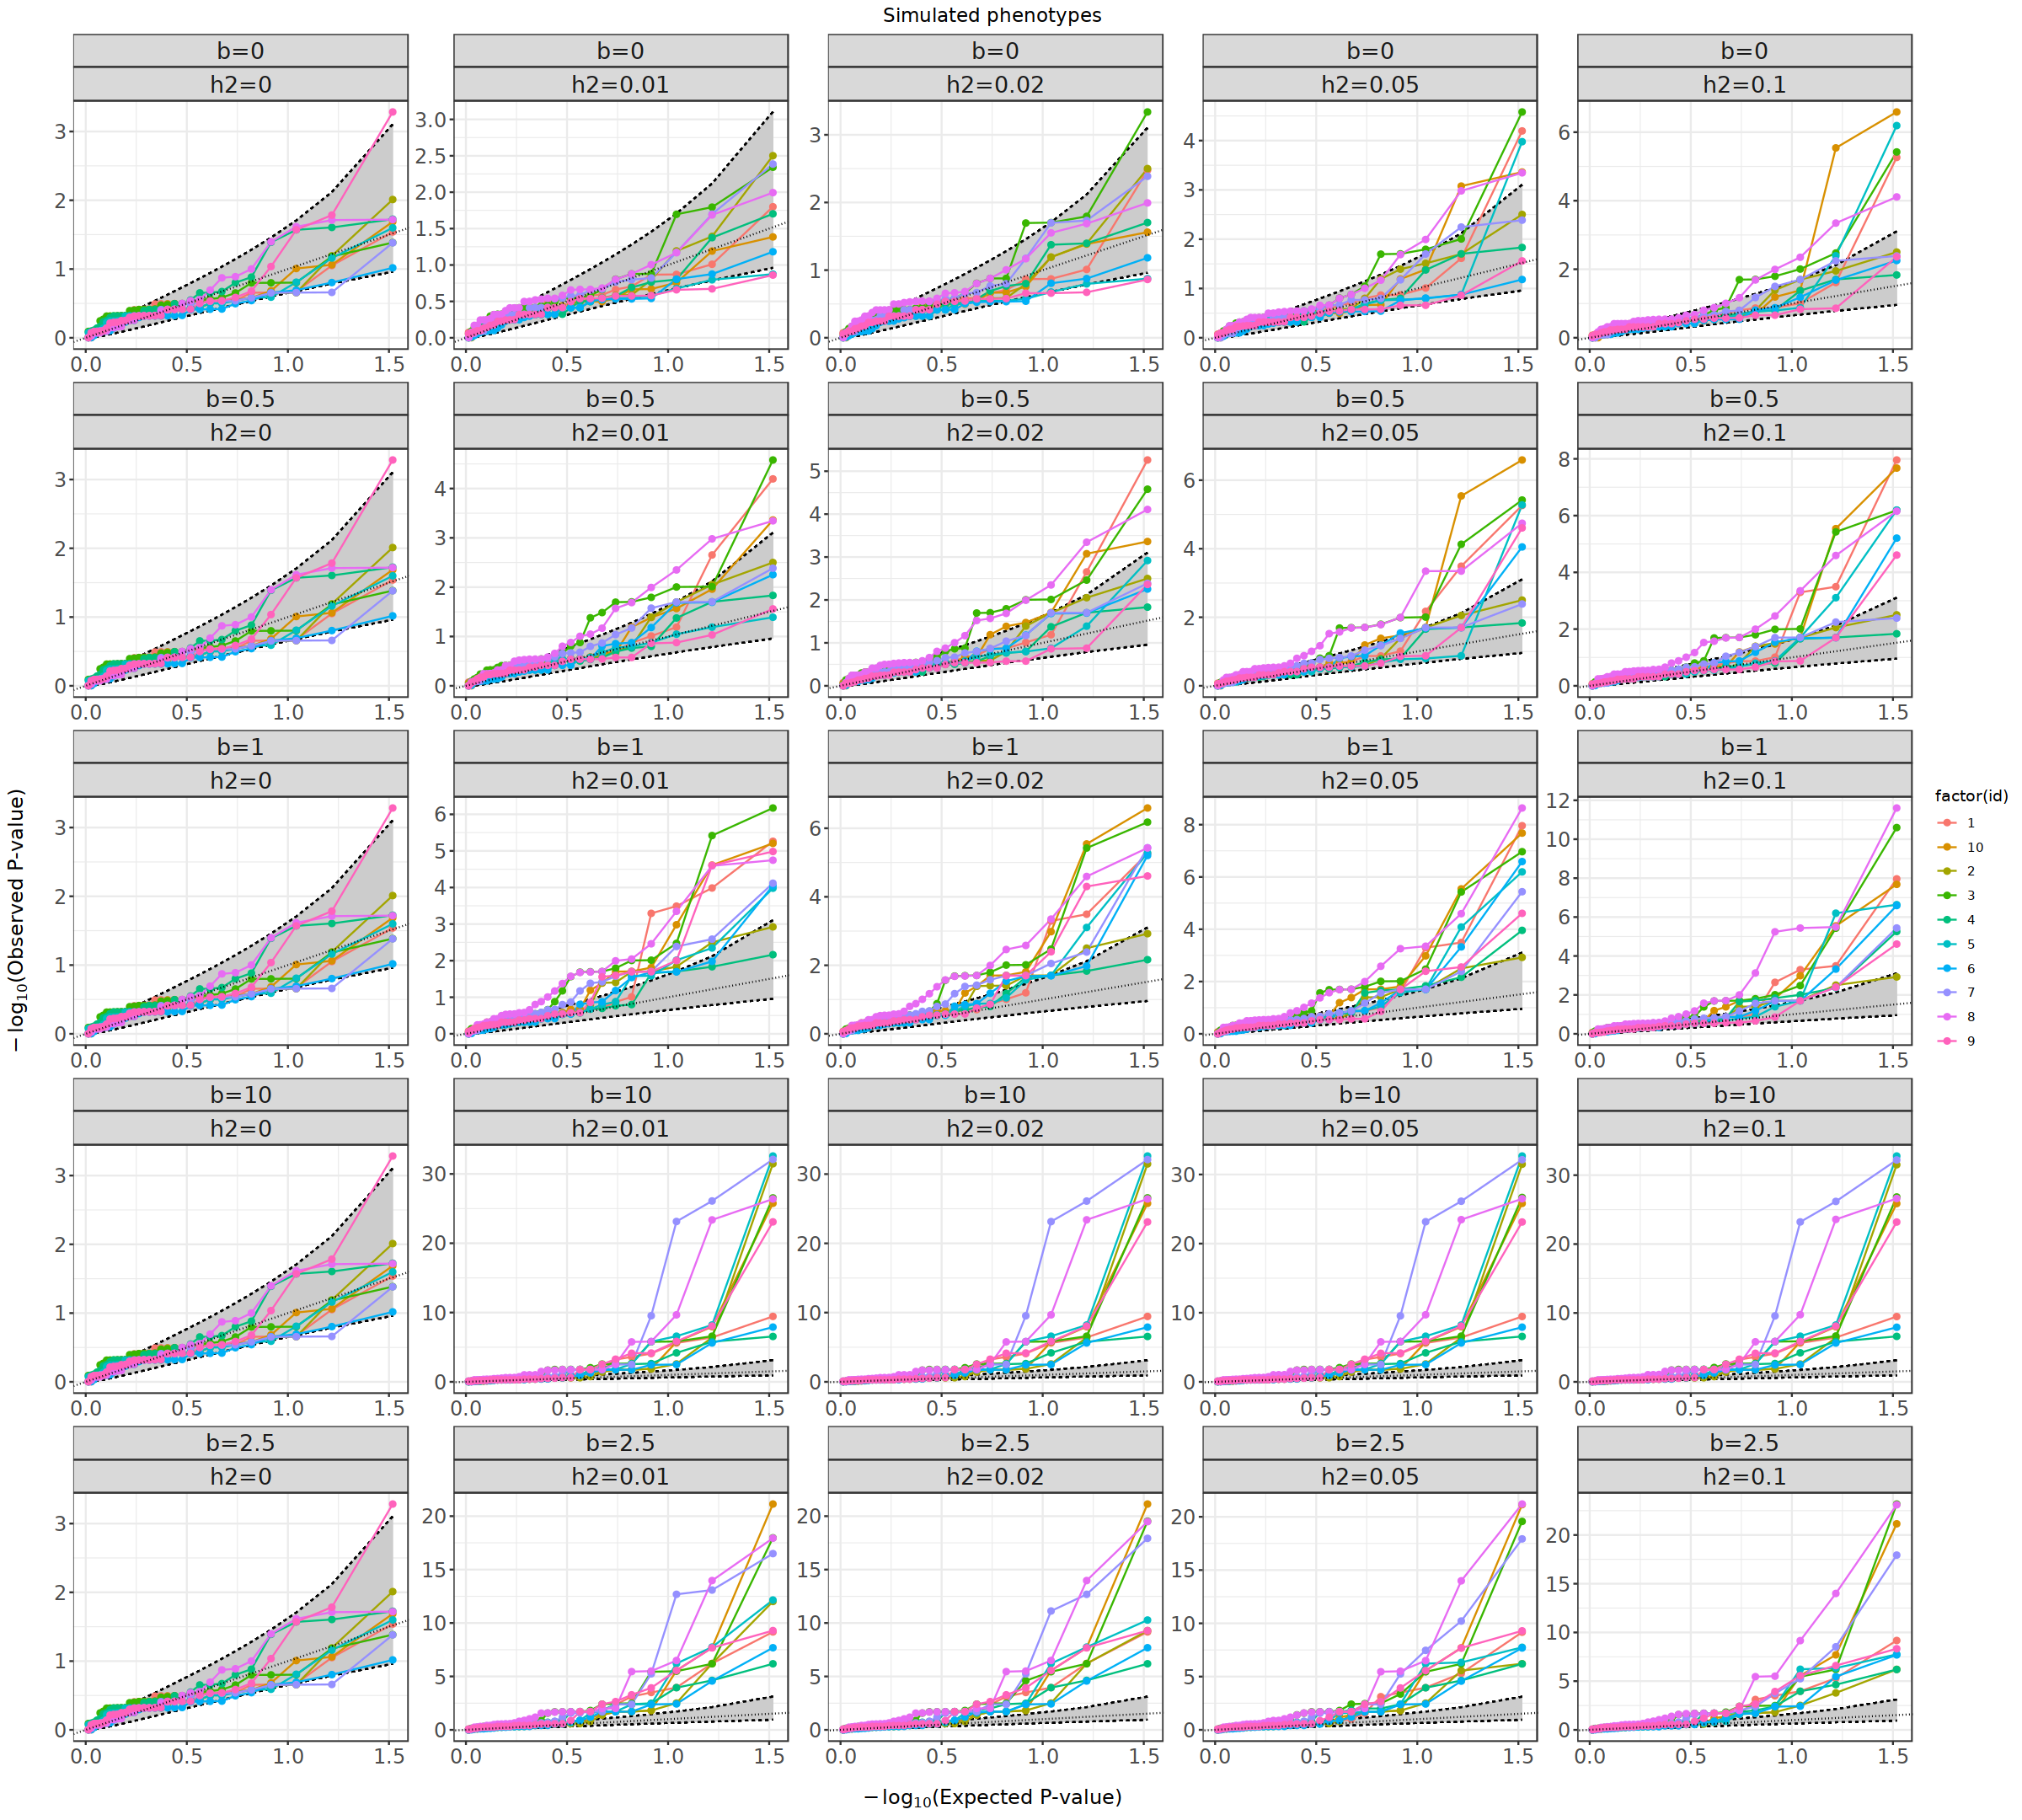

In [113]:
ggplot(final_df, aes(x=pvalue.expected, y=pvalue.observed, ymax=cupper, ymin=clower, group = factor(id), color = factor(id))) +
    geom_ribbon(fill="grey80", color="black", alpha = 0.7, linetype = 'dashed') +
    geom_line() +
    geom_point() +
    geom_abline(linetype = 'dotted') + 
    scale_x_continuous(breaks=scales::pretty_breaks(n=5)) +
    scale_y_continuous(breaks=scales::pretty_breaks(n=5)) +
    xlab(expression(paste(-log[10],'(Expected P-value)' ))) +
    ylab(expression(paste(-log[10],'(Observed P-value)' ))) +
    #geom_hline(yintercept = -log10(bonf), linetype = 'dashed', color = 'red') +
    ggtitle("Simulated phenotypes") +
    #facet_wrap(~h2) +
    #facet_grid(b~h2, ) +
    facet_wrap(label_b~label_h2, scales = 'free') +
    theme_bw() +
    theme(
        axis.text=element_text(size=14),
        axis.title=element_text(size=14,face="bold"),
        axis.title.x = element_text(margin=ggplot2::margin(t=16)),
        axis.title.y = element_text(margin=ggplot2::margin(r=16)),
        plot.title = element_text(hjust=0.5),
        plot.subtitle = element_text(hjust=0.5),
            strip.text = element_text(size=16),
        legend.position="right"
    )

In [116]:
ggsave("derived/plots/230503_sim_qq_plot.pdf", width=16, height=14)

In [58]:
h2s <- unique(final_df$h2)
h2s <- h2s[h2s!=0] # can't calculate ROC if there are no TRUE positives
bs <- unique(final_df$b)

In [60]:
#head(final_df[final_df$h2 == 0,])

In [65]:
lst <- list()
for (cur_h2 in h2s){
    for (cur_b in bs){
        cur_df <- final_df[(final_df$h2 == cur_h2) & (final_df$b == cur_b)]
        plims <- c(min(cur_df$pvalue), max(cur_df$pvalue))
        pseq <- seq_log(from=plims[1], to=plims[2], length.out=5000)
        dt <- rbindlist(lapply(pseq, function(p){
            cur_df_by_p <- cur_df
            total <- nrow(cur_df)
            bool_true_positive <- ((cur_df_by_p$theta != 0) & (cur_df$pvalue <= p))
            bool_true_negative <- ((cur_df_by_p$theta == 0) & (cur_df$pvalue > p))
            bool_false_positive <- ((cur_df_by_p$theta == 0) & (cur_df$pvalue <= p))
            bool_false_negative <- ((cur_df_by_p$theta != 0) & (cur_df$pvalue > p))
            sensitivity <- sum(bool_true_positive) / (sum(bool_true_positive)+sum(bool_false_negative))
            specificity <- sum(bool_true_negative)/ (sum(bool_true_negative)+sum(bool_false_positive))
            return(data.table(p, sensitivity, specificity))
        }))
        dt$b <- cur_b
        dt$h2 <- cur_h2
        outname <- paste0("h2=", cur_h2,", b=",cur_b)
        dt$id <- outname
        lst[[outname]] <- dt
    }
}

In [66]:
roc_data <- rbindlist(lst)
roc_data$h2_label <- paste0("h2=",roc_data$h2)

In [67]:
colfunc<-colorRampPalette(c("grey","tomato1"))#))
#plot(rep(1,4),col=(colfunc(4)), pch=19,cex=2)
bs <- unique(roc_data$b)
my_colors <- colfunc(length(bs))
names(my_colors) <- bs
color_scale <- scale_color_manual(name = "b", values = my_colors)

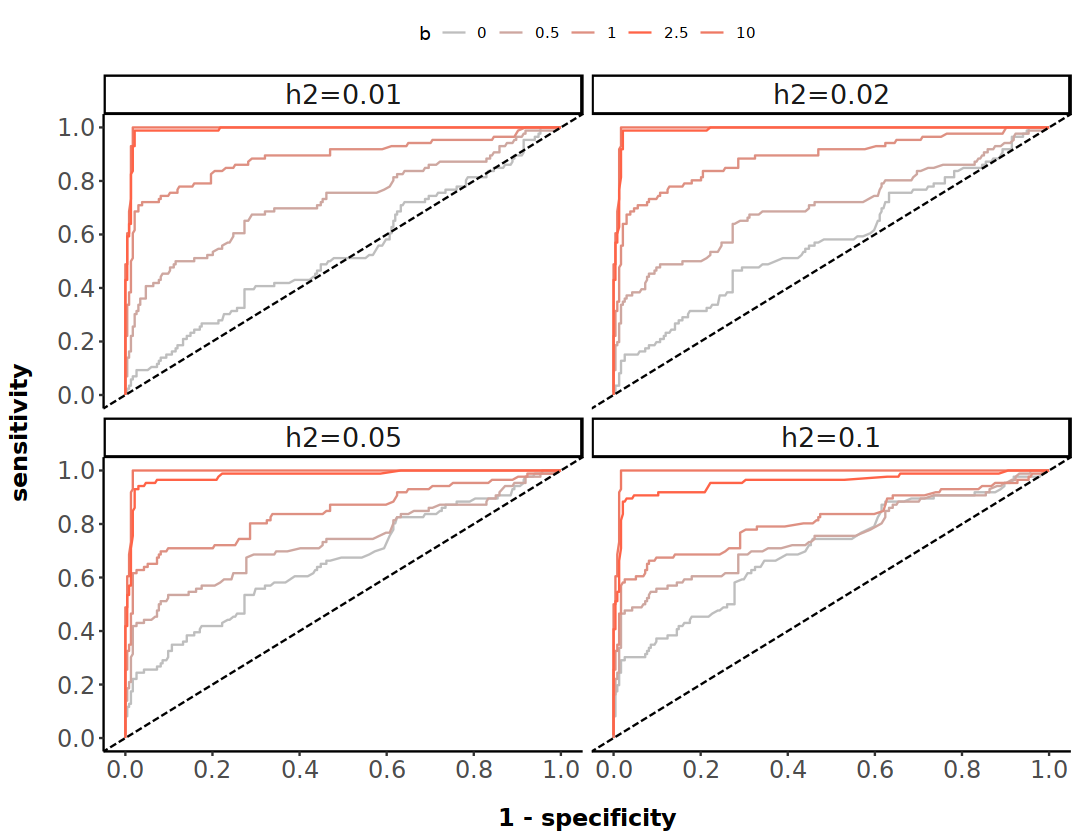

In [118]:
options(repr.plot.width=9, repr.plot.height=7)
ggplot(roc_data, aes(y=sensitivity, x=1-specificity, color=factor(b), group=factor(id))) +
    #geom_point(size=0.5) +
    geom_line() +
    geom_abline(linetype = 'longdash') +
    scale_x_continuous(breaks=scales::pretty_breaks(n=5)) +
    scale_y_continuous(breaks=scales::pretty_breaks(n=5)) +
    theme_classic() +
    labs(color="Average effect (b)") +
    color_scale + 
    theme(
        axis.text=element_text(size=14),
        axis.title=element_text(size=14,face="bold"),
        axis.title.x = element_text(margin=ggplot2::margin(t=16)),
        axis.title.y = element_text(margin=ggplot2::margin(r=16)),
        plot.title = element_text(hjust=0.5),
        plot.subtitle = element_text(hjust=0.5),
        strip.text = element_text(size=16),
        legend.position="top"
    ) + facet_wrap(~h2_label)

ggsave("derived/plots/230503_sim_roc_plot.pdf", width=8, height=6)

In [79]:
# get AUC
approximate_auc <- function(sensitivity, specificity){
    require(zoo)
    x <- 1-specificity
    y <- sensitivity
    id <- order(x)
    return(sum(diff(x[id])*rollmean(y[id],2)))
}

aucs <- rbindlist(lapply(h2s, function(cur_h2){
    rbindlist(lapply(bs, function(cur_b){
        auc_data <- roc_data[roc_data$h2 == cur_h2 & roc_data$b == cur_b]
        auc <- approximate_auc( auc_data$sensitivity, auc_data$specificity)
        data.table(h2=cur_h2, b=cur_b, auc=auc)
    }))
}))

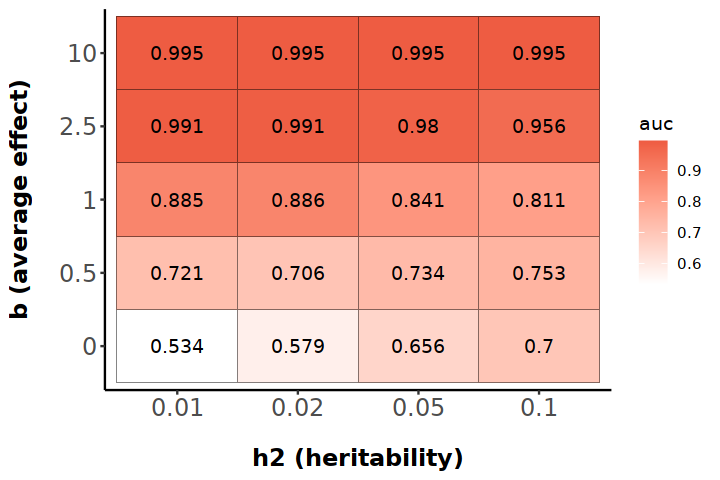

In [119]:
options(repr.plot.width=6, repr.plot.height=4)
ggplot(aucs, aes(x=factor(h2), y=factor(b), fill=auc, label=round(auc,3))) +
    geom_tile(color='black') +
    geom_text() +
    scale_fill_gradient(low="white", high="tomato2") +
    theme_classic() +
    xlab("h2 (heritability)") +
    ylab("b (average effect)") +
    theme(
        axis.text=element_text(size=14),
        axis.title=element_text(size=14,face="bold"),
        axis.title.x = element_text(margin=ggplot2::margin(t=16)),
        axis.title.y = element_text(margin=ggplot2::margin(r=16)),
        plot.title = element_text(hjust=0.5),
        plot.subtitle = element_text(hjust=0.5),
        strip.text = element_text(size=16),
        legend.position="right"
    ) 

In [120]:
ggsave("derived/plots/230503_sim_auc_plot.pdf", width=7, height=5)

In [69]:
get_new_qq <- function(d, ribbon_p=0.95){
    n <- nrow(d)
    return(
        data.frame(
            pvalue.observed=sort(-log10(d$pvalue)),
            pvalue.expected=sort(-log10(get_expected_p(d$pvalue))),
            clower = sort(-log10(qbeta(p = (1 - ribbon_p) / 2, shape2 = n:1, shape1 = 1:n))),
            cupper = sort(-log10(qbeta(p = (1 + ribbon_p) / 2, shape2 = n:1, shape1 = 1:n)))
        )
    )
}

In [70]:
# get true negatives
final_df_true_neg <- final_df[final_df$theta==0,]
final_df_true_neg <- get_new_qq(final_df_true_neg)
final_df_true_neg$comparison <- "beta=0"
final_df_true_pos <- final_df[final_df$theta!=0,]
final_df_true_pos <- get_new_qq(final_df_true_pos)
final_df_true_pos$comparison <- "abs(beta)>0"
final_df_all <- get_new_qq(final_df)
final_df_all$comparison <- "Everything"
combined <- rbind(final_df_true_neg, final_df_true_pos, final_df_all)

#n <- nrow(final_df_true_neg)
#final_df_true_neg <- data.frame(
#    pvalue.observed=sort(-log10(final_df_true_neg$pvalue)),
#    pvalue.expected=sort(-log10(get_expected_p(final_df_true_neg$pvalue))),
#    clower = sort(-log10(qbeta(p = (1 - ribbon_p) / 2, shape2 = n:1, shape1 = 1:n))),
#    cupper = sort(-log10(qbeta(p = (1 + ribbon_p) / 2, shape2 = n:1, shape1 = 1:n)))
#)


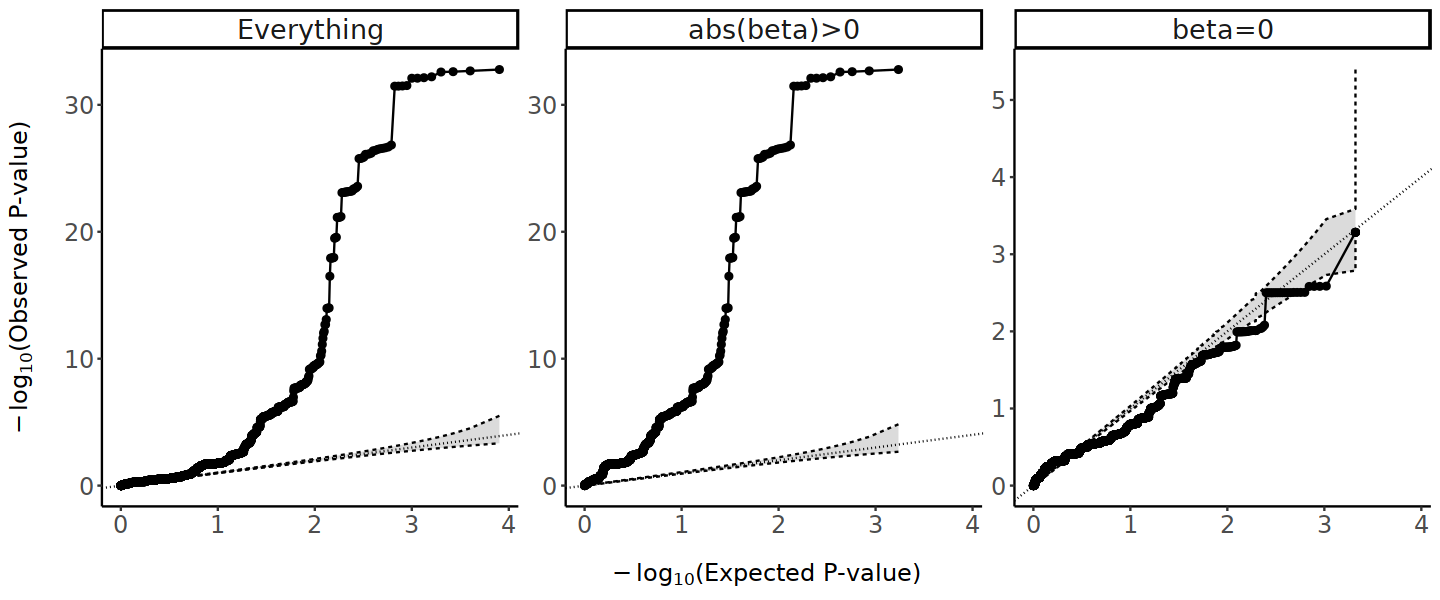

In [71]:
options(repr.plot.width=12, repr.plot.height=5)
ggplot(combined, aes(x=pvalue.expected, y=pvalue.observed, ymax=cupper, ymin=clower)) +
    geom_ribbon(fill="grey80", color="black", alpha = 0.7, linetype = 'dashed') +
    geom_line() +
    geom_point() +
    geom_abline(linetype = 'dotted') + 
    scale_x_continuous(breaks=scales::pretty_breaks(n=5)) +
    scale_y_continuous(breaks=scales::pretty_breaks(n=5)) +
    xlab(expression(paste(-log[10],'(Expected P-value)' ))) +
    ylab(expression(paste(-log[10],'(Observed P-value)' ))) +
    facet_wrap(~comparison, nrow=1, scale="free_y") +
    theme_classic() +
    theme(
        axis.text=element_text(size=14),
        axis.title=element_text(size=14,face="bold"),
        axis.title.x = element_text(margin=ggplot2::margin(t=16)),
        axis.title.y = element_text(margin=ggplot2::margin(r=16)),
        plot.title = element_text(hjust=0.5),
        plot.subtitle = element_text(hjust=0.5),
            strip.text = element_text(size=16),
        legend.position="right"
    )

# Old model

In [2]:
#d <- fread("data/simulation/saige/step2/ukb_eur_h2_0.00_var_0.00_0.00_pi_0.01_0.01_K0.1_chr22_y_1_pLoF_damaging_missense.txt")

In [3]:
#p <- fread("data/simulation/phenotypes/_1_cols.tsv.gz")

In [4]:
#d <- fread("data/simulation/phenotypes/ukb_eur_h2_0.001_var_0.10_99.0_pi_0.20_0.20_K0.1_seed504_chr22_1_cols.tsv.gz")
#d <- fread("data/simulation/phenotypes/ukb_eur_h2_0.001_var_0.10_99.0_pi_0.20_0.20_K0.1_seed604_chr22_1_cols.tsv.gz")

In [5]:
#d <- fread("data/simulation/phenotypes/ukb_eur_h2_0.001_var_10.0_0.10_pi_0.20_0.20_K0.1_seed501_chr22_1_cols.tsv.gz")
d <- fread("data/simulation/phenotypes/ukb_wes_union_calls_h2_0.05_var_99.0_0.10_pi_0.20_0.20_K0.1_seed106_chr22_3_cols.tsv.gz")
#d <- fread("data/simulation/phenotypes/ukb_wes_union_calls_h2_0.05_var_0.10_99.0_pi_0.20_0.20_K0.1_seed106_chr22_3_cols.tsv.gz")

In [6]:
print(paste("additive: ",  var(d$y_no_noise_add) / var(d$y_no_noise)))
print(paste("recessive: ", var(d$y_no_noise_rec) / var(d$y_no_noise)))


[1] "additive:  0.999989626745495"
[1] "recessive:  1.37099986652995e-05"


In [7]:
mean(d$y_no_noise_add)
mean(d$y_no_noise_rec)

[1] -4.6718e-06

[1] -0.08599275

# Simulate absence of effects

In [8]:
#pattern <- "ukb_eur_h2_0.00_var_0.00_0.00_pi_0.01_0.01_K0.1_chr22"
#pattern <- "ukb_eur_h2_0.30_var_0.01_1_pi_1.00_1.00_K0.1_chr22"
pattern <- "ukb_eur_h2_0.30_var_0.01_0.01_pi_1.00_1.00_K0.1_chr22"
files <- list.files("data/simulation/saige/step2/binary", pattern = ".txt$", full.names = TRUE)
#files <- files[!grepl("index", files)][1:49]


In [6]:
# get corresponding simulation file
grab_sim_file <- function(file, simdir = "data/simulation/phenotypes/", hail = "cols"){
    f <- gsub("(_pLoF_damaging_missense.txt)|(case_)","",basename(file))
    f <- paste0(simdir,f, "_",hail,".tsv.gz")
    if (!file.exists(f)) stop(paste(f, "could not be found!"))
    return(f)
}

get_qq_df <- function(files, get_sim_file = FALSE){
    ribbon_p <- 0.95
    d <- do.call(rbind, lapply(files, function(f){
        stopifnot(file.exists(f))
        d <- fread(f)
        
        extracted_pi <- gsub("(pi_)|(_K)","",stringr::str_extract(basename(f), "pi.+K"))
        extracted_vars <- gsub("(var_)|(_pi)","",stringr::str_extract(basename(f), "var.+pi"))
        pis <- unlist(strsplit(extracted_pi, split = '_'))
        vars <- unlist(strsplit(extracted_vars, split = '_'))
        
        if (nrow(d) > 0){
            
            # get qq-plot data
            
            # need to order this and keed cases and controls to check inflation
            #d <- d[]
            d$p.value.expt <- get_expected_p(d$p.value, na.rm = TRUE)
            n <- length(d$p.value)
            dt <- data.table(
                ensembl_gene_id = d$MarkerID[order(d$p.value)],
                pvalue.observed = -log10(sort(d$p.value)),
                pvalue.expected = -log10(sort(d$p.value.expt)),
                clower = -log10(qbeta(p = (1 - ribbon_p) / 2, shape2 = n:1, shape1 = 1:n)),
                cupper = -log10(qbeta(p = (1 + ribbon_p) / 2, shape2 = n:1, shape1 = 1:n)),
                #gsub("(pLoF_damaging_missense.txt)|(ukb_eur_)|(K0.1_)|(_chr22)", "", basename(f)),
                #phenofile = gsub("_pLoF_damaging_missense.txt","_phenos.tsv.gz", basename)
                h2 = as.numeric(gsub("(h2_)|(_var)","",stringr::str_extract(basename(f), "h2.+var"))),
                seed = as.numeric(gsub("(seed)|(_chr)","",stringr::str_extract(basename(f), "seed.+chr"))),
                pi_1 = as.numeric(pis[1]),
                pi_2 = as.numeric(pis[2]),
                var_1 = as.numeric(vars[1]),
                var_2 = as.numeric(vars[2])
            )
            
            # grab actual file used for simulation
            if (get_sim_file){
                simfile <- grab_sim_file(f)
                dsim <- fread(simfile)
                dt$sim_h2 <- round(var(dsim$y_no_noise_rescaled), 5)
                dt$sim_y <- round(var(dsim$y))
                dt$sim_cases <- sum(dsim$case)
                dt$sim_controls <- sum(!dsim$case)
                dt$var_by_rec <- var(dsim$y_no_noise_rec) / (var(dsim$y_no_noise_add) + var(dsim$y_no_noise_rec))
                dt$var_by_rec <- round(dt$var_by_rec, 4)
            }
            
            dt$fname <- basename(f)
            return(dt)
        } else {
            return(NULL)
        }
    }))
    d$label <- factor(paste0("sim",d$seed), levels = paste0("sim",1:100))
    return(d)
}

In [10]:
d <- fread(files[1])
head(d)

CHR,POS,MarkerID,Allele1,Allele2,AC_Allele2,AF_Allele2,MissingRate,BETA,SE,⋯,p.value.NA,Is.SPA,AF_case,AF_ctrl,N_case,N_ctrl,N_case_hom,N_case_het,N_ctrl_hom,N_ctrl_het
<chr>,<int>,<chr>,<chr>,<chr>,<int>,<dbl>,<int>,<dbl>,<dbl>,⋯,<dbl>,<lgl>,<dbl>,<dbl>,<int>,<int>,<int>,<int>,<int>,<int>
chr22,19,ENSG00000075275,twGh,ZiSv,34,1.70353e-04,0,0.267773,0.409983,⋯,0.5136705,FALSE,0.000250803,1.61425e-04,9968,89825,2,1,14,1
chr22,33,ENSG00000099937,HCKS,QJXT,6,3.00622e-05,0,-0.555038,0.964991,⋯,0.5651733,FALSE,0.000000000,3.33983e-05,9968,89825,0,0,3,0
chr22,40,ENSG00000099957,klbM,DHIi,10,5.01037e-05,0,-0.555612,0.744406,⋯,0.4554360,FALSE,0.000000000,5.56638e-05,9968,89825,0,0,5,0
chr22,42,ENSG00000099960,Seqn,yjKc,8,4.00830e-05,0,-0.555991,0.830266,⋯,0.5030780,FALSE,0.000000000,4.45310e-05,9968,89825,0,0,4,0
chr22,54,ENSG00000100012,etAz,kviM,100,5.01037e-04,0,-0.113449,0.236724,⋯,0.6317641,FALSE,0.000401284,5.12107e-04,9968,89825,4,0,45,2
chr22,71,ENSG00000100068,TXkq,luQN,83,4.15861e-04,0,-0.289198,0.259670,⋯,0.2654022,FALSE,0.000200642,4.39744e-04,9968,89825,2,0,39,1


In [19]:
get_qq_df2 <- function(files, get_sim_file = FALSE){
    ribbon_p <- 0.95
    d <- do.call(rbind, lapply(files, function(f){
        stopifnot(file.exists(f))
        d <- fread(f)
        
        extracted_pi <- gsub("(pi_)|(_K)","",stringr::str_extract(basename(f), "pi.+K"))
        extracted_vars <- gsub("(var_)|(_pi)","",stringr::str_extract(basename(f), "var.+pi"))
        pis <- unlist(strsplit(extracted_pi, split = '_'))
        vars <- unlist(strsplit(extracted_vars, split = '_'))
        
        if (nrow(d) > 0){
            
            # get qq-plot data
            d <- d[order(d$p.value),]
            # need to order this and keed cases and controls to check inflation
            d$p.value.expt <- get_expected_p(d$p.value, na.rm = TRUE)
            n <- length(d$p.value)
            dt <- data.table(
                ensembl_gene_id = d$MarkerID, # [order(d$p.value)],
                pvalue = d$p.value,
                pvalue.observed = -log10(d$p.value),
                pvalue.expected = -log10(d$p.value.expt),
                clower = -log10(qbeta(p = (1 - ribbon_p) / 2, shape2 = n:1, shape1 = 1:n)),
                cupper = -log10(qbeta(p = (1 + ribbon_p) / 2, shape2 = n:1, shape1 = 1:n)),
                #gsub("(pLoF_damaging_missense.txt)|(ukb_eur_)|(K0.1_)|(_chr22)", "", basename(f)),
                #phenofile = gsub("_pLoF_damaging_missense.txt","_phenos.tsv.gz", basename)
                h2 = as.numeric(gsub("(h2_)|(_var)","",stringr::str_extract(basename(f), "h2.+var"))),
                seed = as.numeric(gsub("(seed)|(_chr)","",stringr::str_extract(basename(f), "seed.+chr"))),
                pi_1 = as.numeric(pis[1]),
                pi_2 = as.numeric(pis[2]),
                var_1 = as.numeric(vars[1]),
                var_2 = as.numeric(vars[2]),
                AC_allele2 = as.numeric(d$AC_Allele2),
                N_case_hom = as.numeric(d$N_case_hom),
                N_ctrl_hom = as.numeric(d$N_ctrl_hom)
            )
            
            # grab actual file used for simulation
            if (get_sim_file){
                print(f)
                simfile <- grab_sim_file(f)
                dsim <- fread(simfile)
                dt$sim_h2 <- round(var(dsim$y_no_noise_rescaled), 5)
                dt$sim_y <- round(var(dsim$y))
                dt$sim_cases <- sum(dsim$case)
                dt$sim_controls <- sum(!dsim$case)
                dt$var_by_rec <- var(dsim$y_no_noise_rec) / (var(dsim$y_no_noise_add) + var(dsim$y_no_noise_rec))
                dt$var_by_rec <- round(dt$var_by_rec, 4)
            }
            
            dt$fname <- basename(f)
            return(dt)
        } else {
            return(NULL)
        }
    }))
    d$label <- factor(paste0("sim",d$seed), levels = paste0("sim",1:100))
    return(d)
}

In [20]:
#d <- get_qq_df(files)

ERROR while rich displaying an object: Error: Must request at least one colour from a hue palette.

Traceback:
1. FUN(X[[i]], ...)
2. tryCatch(withCallingHandlers({
 .     if (!mime %in% names(repr::mime2repr)) 
 .         stop("No repr_* for mimetype ", mime, " in repr::mime2repr")
 .     rpr <- repr::mime2repr[[mime]](obj)
 .     if (is.null(rpr)) 
 .         return(NULL)
 .     prepare_content(is.raw(rpr), rpr)
 . }, error = error_handler), error = outer_handler)
3. tryCatchList(expr, classes, parentenv, handlers)
4. tryCatchOne(expr, names, parentenv, handlers[[1L]])
5. doTryCatch(return(expr), name, parentenv, handler)
6. withCallingHandlers({
 .     if (!mime %in% names(repr::mime2repr)) 
 .         stop("No repr_* for mimetype ", mime, " in repr::mime2repr")
 .     rpr <- repr::mime2repr[[mime]](obj)
 .     if (is.null(rpr)) 
 .         return(NULL)
 .     prepare_content(is.raw(rpr), rpr)
 . }, error = error_handler)
7. repr::mime2repr[[mime]](obj)
8. repr_text.default(obj)
9. 

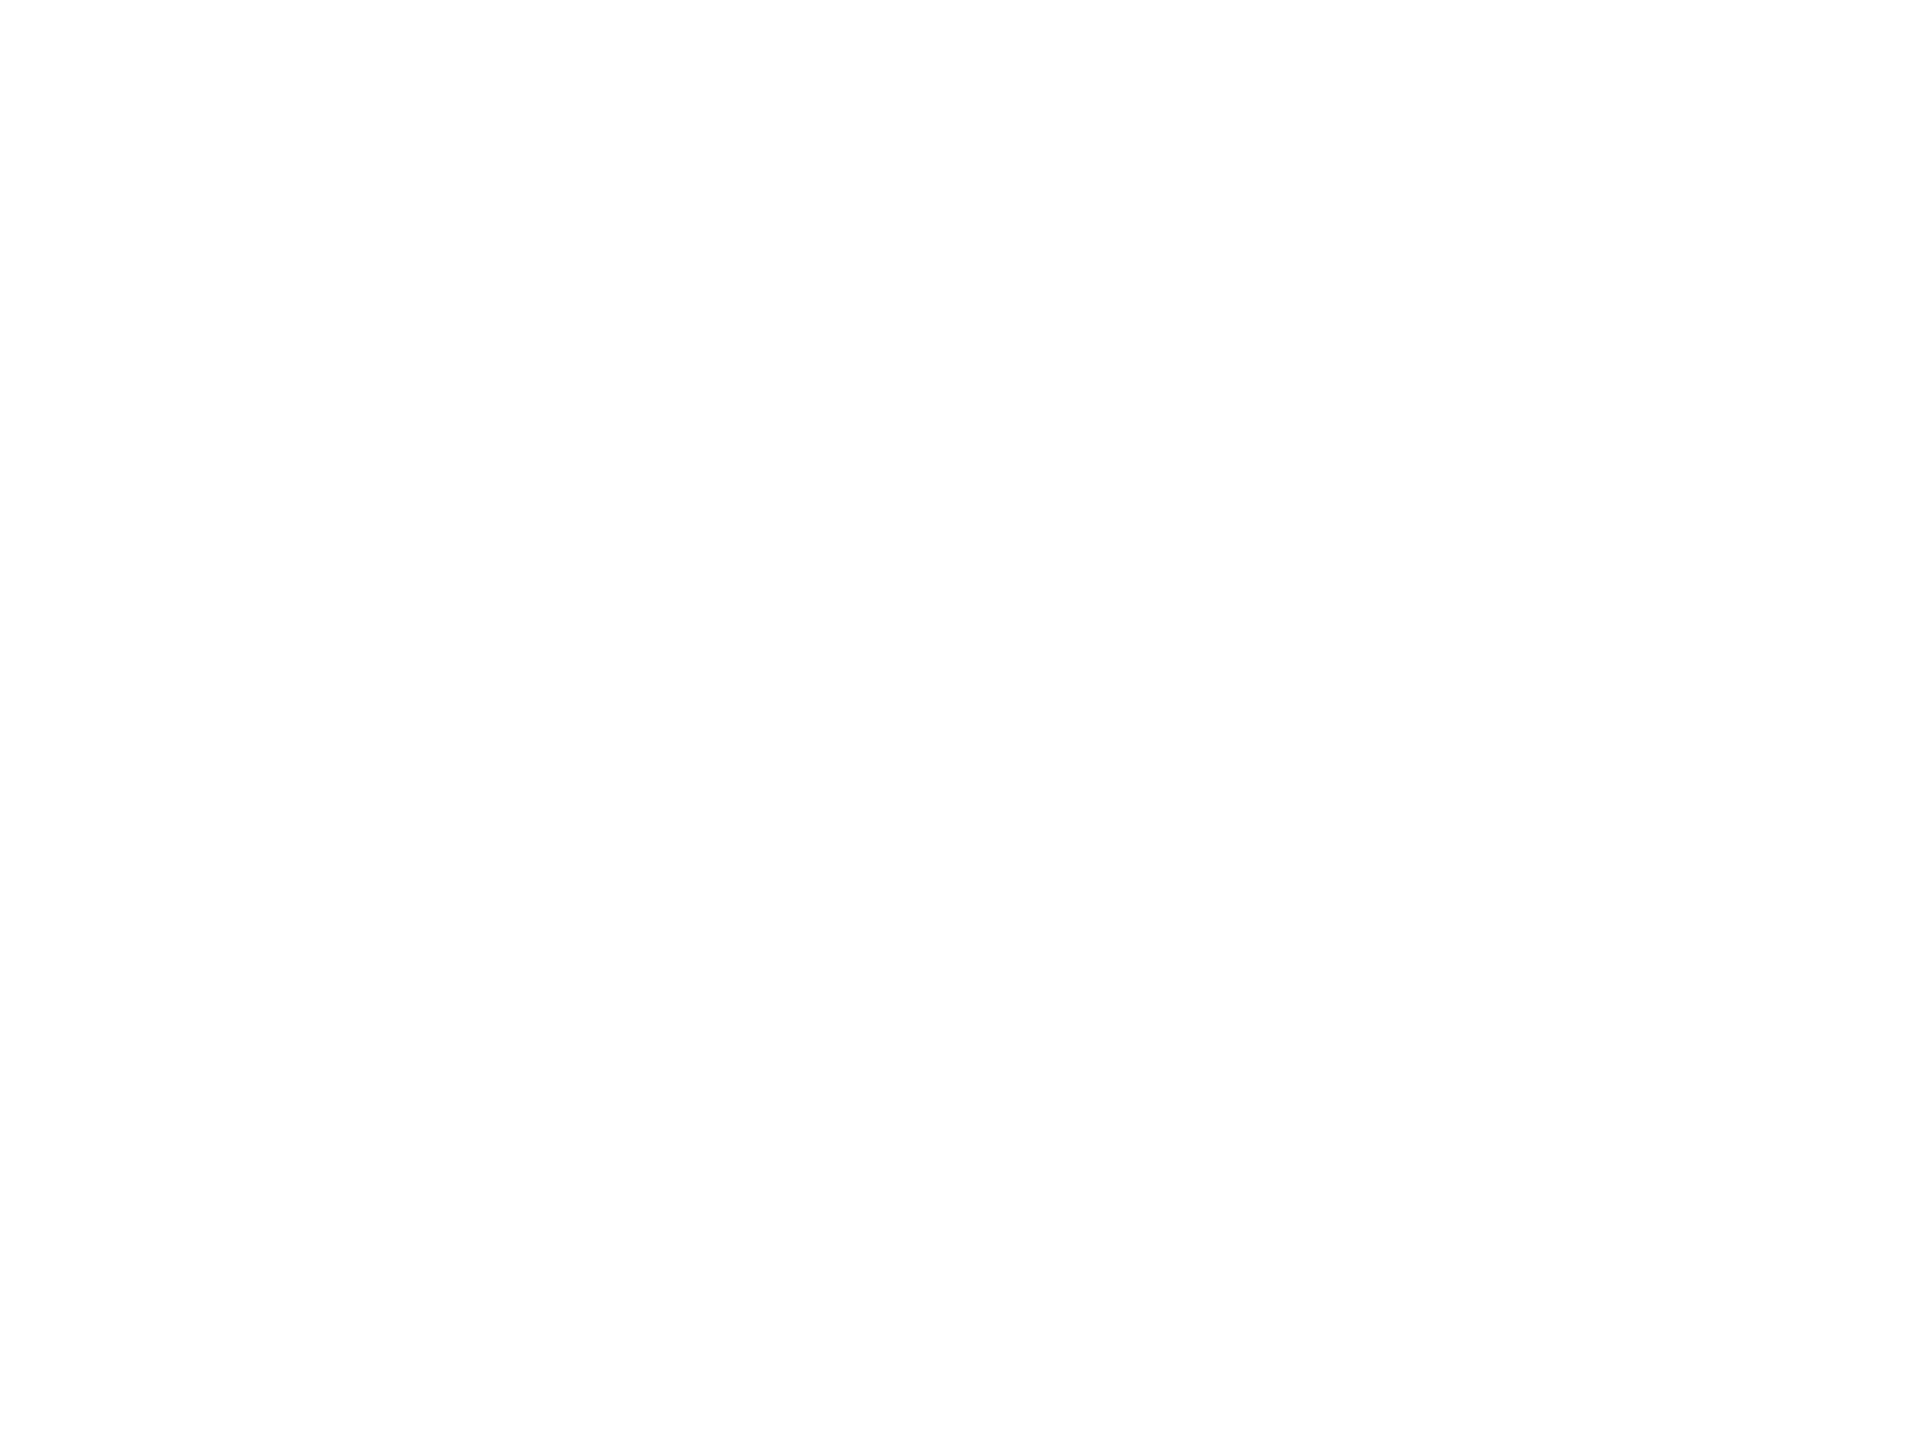

In [21]:
options(repr.plot.width=16, repr.plot.height=12)
bonf <- 0.05 / (length(unique(d$ensembl_gene_id)) * length(unique(d$seed)))
ggplot(d, aes(x=pvalue.expected, y=pvalue.observed, ymax=cupper, ymin=clower, group = label, color = label)) +
    geom_ribbon(fill="grey80", color="black", alpha = 0.1, linetype = 'dashed') +
    geom_line() +
    geom_point() +
    geom_abline(linetype = 'dotted') + 
    scale_x_continuous(breaks=scales::pretty_breaks(n=5)) +
    scale_y_continuous(breaks=scales::pretty_breaks(n=5)) +
    xlab(expression(paste(-log[10],'(Expected P-value)' ))) +
    ylab(expression(paste(-log[10],'(Observed P-value)' ))) +
    #geom_hline(yintercept = -log10(bonf), linetype = 'dashed', color = 'red') +
    ggtitle("Simulation of absence of effects") +
    facet_wrap(~label) +
    theme_bw() +
    theme(
        axis.text=element_text(size=14),
        axis.title=element_text(size=14,face="bold"),
        axis.title.x = element_text(margin=ggplot2::margin(t=16)),
        axis.title.y = element_text(margin=ggplot2::margin(r=16)),
        plot.title = element_text(hjust=0.5),
        plot.subtitle = element_text(hjust=0.5),
        legend.position="none"
    )

# Simulate additive effects

In [14]:
pattern <- "seed10"
files <- list.files("data/simulation/saige/step2/binary", pattern = pattern, full.names = TRUE)
files <- files[!grepl("index", files)]
files <- files[grepl("var_0.10", files)] #files[grepl("var_99.0", files)] #files[grepl("var_0.10", files)] #
#files <- head(files, n = 2)
#files <- files[grepl(files, pattern = "h2_0.00_")]
length(files)

[1] 300

In [15]:
d <- get_qq_df2(files, get_sim_file = FALSE)

In [16]:
get_entry_file <- function(x){
    directory <- "data/simulation/phenotypes/"
    y <- gsub("(_case)","",x)
    y <- gsub("\\.txt", "", y)
    final <- paste0(directory,y,'_entries.tsv.gz')
    return(final)
}

In [17]:
d$fentry <- get_entry_file(d$fname)
file_df <- d[,c("fname","fentry")]
file_df <- file_df[!duplicated(file_df)]
file_df$h2 <- as.numeric(gsub("(h2_)|(_var)","",stringr::str_extract(basename(file_df$fname), "h2.+var")))
file_df$seed <- as.numeric(gsub("(seed)|(_chr)","",stringr::str_extract(basename(file_df$fname), "seed.+chr")))
file_df$id <- as.numeric(gsub("(case_)|(_pLoF)","",stringr::str_extract(basename(file_df$fname), "case.+pLoF")))

In [18]:
idx <- 1
write(idx, stderr())
file_entry <- file_df$fentry[idx]
file_saige <- file_df$fname[idx]
command <- paste("zcat",file_entry,"| grep -v NA")
entry_dt <- fread(cmd = command)
file_entry

[1] "data/simulation/phenotypes/ukb_wes_union_calls_h2_0.001_var_0.10_99.0_pi_0.20_0.20_K0.1_seed101_chr22_1_entries.tsv.gz"

In [19]:
lst <- lapply(1:nrow(file_df), function(idx){
    write(idx, stderr())
    file_entry <- file_df$fentry[idx]
    file_saige <- file_df$fname[idx]
    command <- paste("zcat",file_entry,"| grep -v NA")
    entry_dt <- fread(cmd = command)
    
    # get knockout count
    ko_dt <- data.table(table(entry_dt$rsid, entry_dt$pKO != 0))
    ko_dt <- ko_dt[ko_dt$V2 == TRUE,]
    ko_dt <- ko_dt[,c("V1","N")]
    colnames(ko_dt) <- c("ensembl_gene_id","N")
    
    # get beta/theta estimates
    entry_dt <- entry_dt[,c("rsid","theta", "beta")]
    entry_dt <- entry_dt[!duplicated(entry_dt),]
    colnames(entry_dt)[1] <- "ensembl_gene_id"
    
    # get pvalue observed
    saige_dt <- d[d$fname %in% file_saige,]
    saige_dt <- saige_dt[,c("ensembl_gene_id","pvalue.observed", "pvalue.expected","clower","cupper")]
    saige_dt <- saige_dt[!duplicated(saige_dt),]
    dt <- merge(entry_dt, saige_dt)
    dt <- merge(dt, ko_dt, all.x = TRUE)
    dt$seed <- file_df$seed[idx]
    dt$h2 <- file_df$h2[idx]
    dt$analysis <- basename(file_saige)
    dt$id <- file_df$id[idx]
    return(dt)
})

In [20]:
combined <- do.call(rbind, lst)
combined$id <- factor(combined$id)
#combined <- combined[combined$h2 != 0.002]

In [21]:
combined$id <- as.numeric(gsub("\\.txt","",stringr::str_extract(combined$analysis, "[0-9]+.txt")))

In [22]:
sum(combined$theta == combined$beta)/nrow(combined)

[1] 0.6422917

In [23]:
colnames(combined)

[1] "ensembl_gene_id" "theta"           "beta"            "pvalue.observed"
 [5] "pvalue.expected" "clower"          "cupper"          "N"              
 [9] "seed"            "h2"              "analysis"        "id"

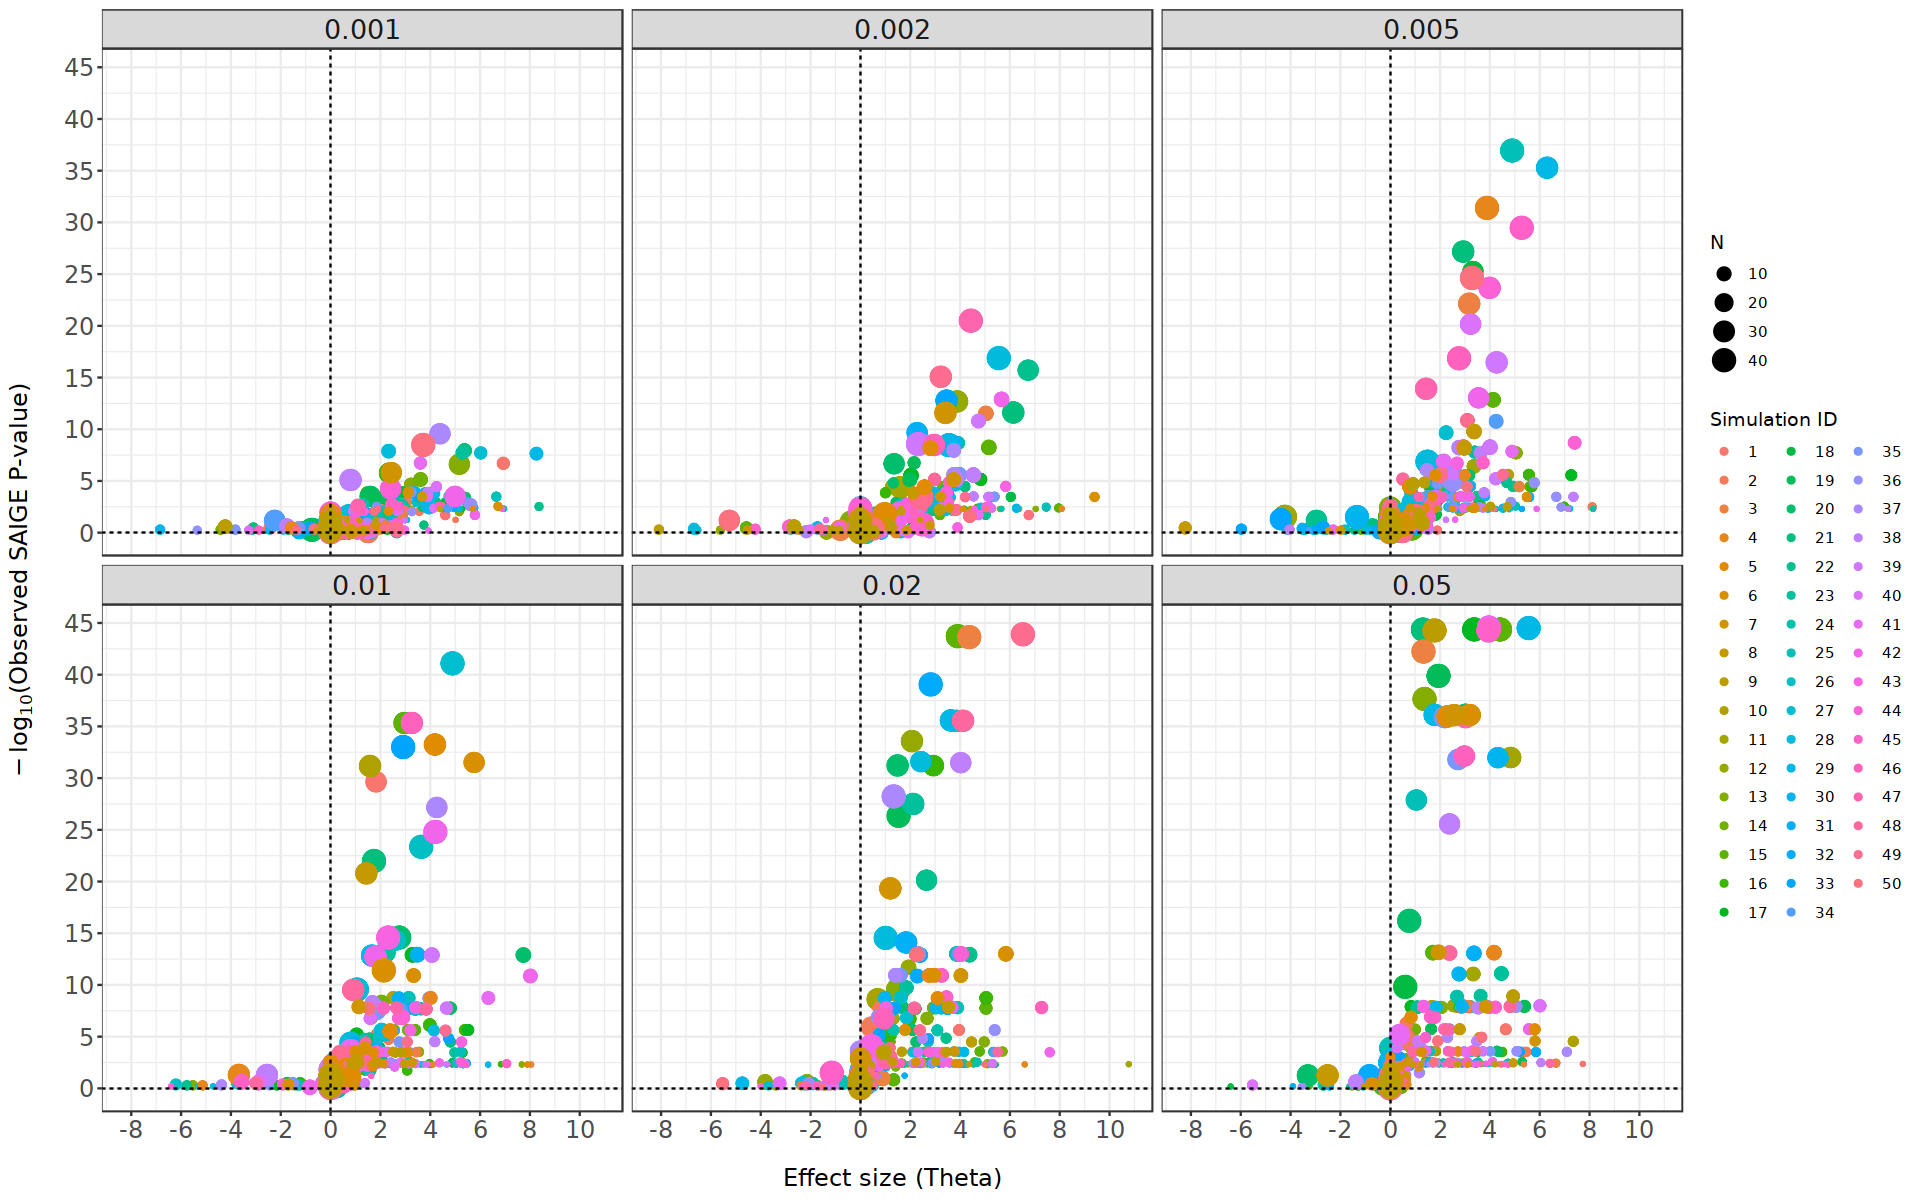

In [33]:
options(repr.plot.width=16, repr.plot.height=10)
ggplot(combined, aes(x=theta, y=pvalue.observed, size = N, color=factor(id))) +
    geom_point_rast() +
    theme_bw() +
    geom_vline(xintercept = 0, linetype = 'dashed') +
    geom_hline(yintercept = 0, linetype = 'dashed') +
    scale_x_continuous(breaks=scales::pretty_breaks(n=10)) +
    scale_y_continuous(breaks=scales::pretty_breaks(n=10)) +
    ylab(expression(paste(-log[10],'(Observed SAIGE P-value)' ))) +
    xlab("Effect size (Theta)") +
    labs(color = "Simulation ID") +
    #facet_wrap(~h2, scales = "free_y") +
    facet_wrap(~h2) +
    theme(
        axis.text=element_text(size=14),
        axis.title=element_text(size=14),
        axis.title.x = element_text(margin=ggplot2::margin(t=16)),
        axis.title.y = element_text(margin=ggplot2::margin(r=16)),
        plot.title = element_text(hjust=0.5),
        plot.subtitle = element_text(hjust=0.5),
        strip.text = element_text(size=16),
        legend.position="right"
    )

In [34]:
ggsave("derived/plots/230324_saige_rec_theta.pdf", width = 14, height = 9)

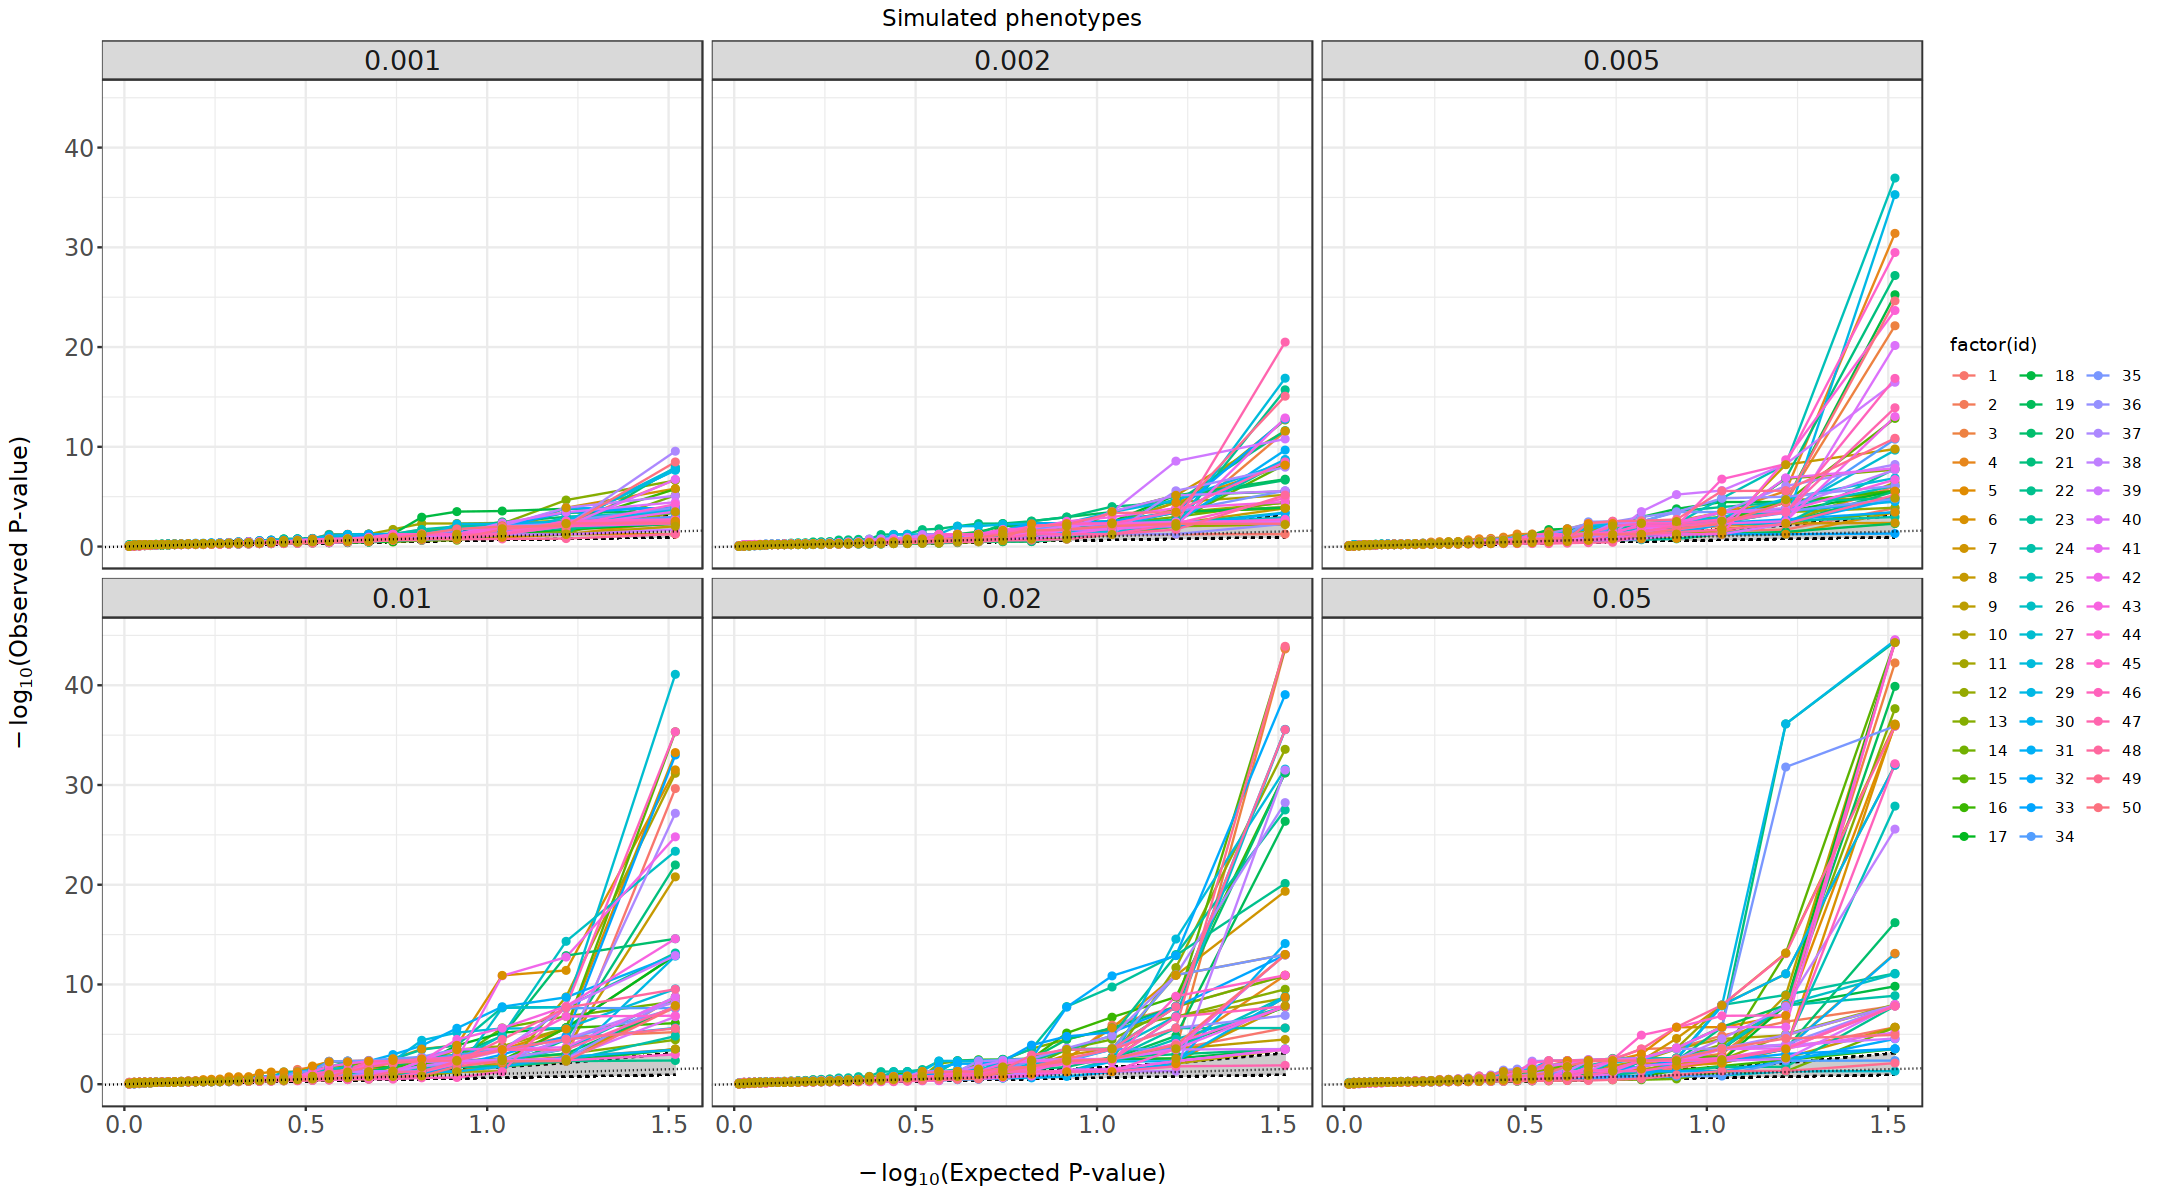

In [35]:
options(repr.plot.width=18, repr.plot.height=10)
#bonf <- 0.05 / (length(unique(d$ensembl_gene_id)) * length(unique(d$seed)))
ggplot(combined, aes(x=pvalue.expected, y=pvalue.observed, ymax=cupper, ymin=clower, group = factor(id), color = factor(id))) +
    geom_ribbon(fill="grey80", color="black", alpha = 0.7, linetype = 'dashed') +
    geom_line() +
    geom_point() +
    geom_abline(linetype = 'dotted') + 
    scale_x_continuous(breaks=scales::pretty_breaks(n=5)) +
    scale_y_continuous(breaks=scales::pretty_breaks(n=5)) +
    xlab(expression(paste(-log[10],'(Expected P-value)' ))) +
    ylab(expression(paste(-log[10],'(Observed P-value)' ))) +
    #geom_hline(yintercept = -log10(bonf), linetype = 'dashed', color = 'red') +
    ggtitle("Simulated phenotypes") +
    facet_wrap(~h2) +
    #facet_wrap(~h2, scales = 'free') +
    theme_bw() +
    theme(
        axis.text=element_text(size=14),
        axis.title=element_text(size=14,face="bold"),
        axis.title.x = element_text(margin=ggplot2::margin(t=16)),
        axis.title.y = element_text(margin=ggplot2::margin(r=16)),
        plot.title = element_text(hjust=0.5),
        plot.subtitle = element_text(hjust=0.5),
            strip.text = element_text(size=16),
        legend.position="right"
    )

In [36]:
ggsave("derived/plots/230324_saige_h2_qq_sim.pdf", width = 14, height = 9)

In [ ]:
plot(lst[[1]]$theta, lst[[1]]$pvalue.observed)

In [104]:

#fname <- "ukb_eur_h2_0.01_var_0.10_99.0_pi_0.20_0.20_K0.1_seed404_chr22_1_entries.tsv.gz"
fname <- "ukb_eur_h2_0.01_var_0.10_0.10_pi_0.20_0.20_K0.1_seed401_chr22_1_entries.tsv.gz"
fname <- "ukb_eur_h2_0.001_var_0.10_99.0_pi_0.20_0.20_K0.1_seed601_chr22_case_1_pLoF_damaging_missense.txt"
path <- paste0(directory, fname)
command <- paste("zcat",path,"| grep -v NA")
d <- fread(cmd = command)

ERROR: Error in paste0(directory, fname): object 'directory' not found


In [63]:
table(d$case, d$beta != 0)
table(d$case, d$theta != 0)

< table of extent 0 x 0 >

< table of extent 0 x 0 >

In [64]:
d <- d[,c("beta", "theta", "rsid")]
d <- d[!duplicated(d),]
colnames(d) <- c("sim_beta","sim_theta", "MarkerID")

ERROR: Error in `[.data.table`(d, , c("beta", "theta", "rsid")): column(s) not found: beta, theta, rsid


In [65]:
fname <- "ukb_eur_h2_0.01_var_0.10_0.10_pi_0.20_0.20_K0.1_seed401_chr22_1_cols.tsv.gz"
path <- paste0(directory, fname)
command <- paste("zcat",path,"| grep -v NA")
cols <- fread(cmd = command)
var(cols$y_no_noise_add); var(cols$y_no_noise_rec); var(cols$y_no_noise); var(cols$y_no_noise_rescaled); var(cols$y)

ERROR: Error in paste0(directory, fname): object 'directory' not found


In [66]:
plot(
    y=cols$y_no_noise, 
    x=cols$y_no_noise[order(cols$y_no_noise)], 
    col = ifelse(cols$case, "red","blue")
)

ERROR: Error in plot(y = cols$y_no_noise, x = cols$y_no_noise[order(cols$y_no_noise)], : object 'cols' not found


In [105]:
#path <- "data/simulation/saige/step2/binary/ukb_eur_h2_0.01_var_0.10_99.0_pi_0.20_0.20_K0.1_seed404_chr22_case_1_pLoF_damaging_missense.txt"
path <- "data/simulation/saige/step2/binary/ukb_eur_h2_0.01_var_0.10_0.10_pi_0.20_0.20_K0.1_seed401_chr22_case_1_pLoF_damaging_missense.txt"
dt <- fread(path)
dt <- merge(d, dt)
plot(dt$sim_beta, -log10(dt$p.value))
plot(dt$sim_theta, -log10(dt$p.value))

ERROR: Error in fread(path): File 'data/simulation/saige/step2/binary/ukb_eur_h2_0.01_var_0.10_0.10_pi_0.20_0.20_K0.1_seed401_chr22_case_1_pLoF_damaging_missense.txt' does not exist or is non-readable. getwd()=='/gpfs3/well/lindgren-ukbb/projects/ukbb-11867/flassen/projects/KO/wes_ko_ukbb'


In [68]:
#options(repr.plot.width=8, repr.plot.height=6)
#ggplot(d, aes(x=log10(var_2), y=var_by_rec)) +
#    geom_point() +
#    theme_bw() +
#    ylab("% variance explained by recessive effects") + 
#    xlab("log10(Variable V2)")

#fname <- grab_sim_file(d$fname[1], hail = 'entries')
#fname
#cmd <- paste("zcat", fname, "| grep -v NA")
#cmd
#test <- fread(cmd = cmd)
#test

In [69]:
d$id <- as.numeric(gsub("\\.txt","",stringr::str_extract(basename(d$fname), "[0-9]+.txt")))
d$id <- factor(d$id)
d_plot <- d
d_plot <- d_plot[(d_plot$AC_allele2 >= 10) & (d_plot$N_case_hom) >= 2,]
#d_plot <- d_plot[(d_plot$AC_allele2 >= 20) ,]


In [70]:
d1 <- d[(d$AC_allele2 >= 0) & (d$N_case_hom >= 0),]
d2 <- d[(d$AC_allele2 >= 10) & (d$N_case_hom >= 0),]
d3 <- d[(d$AC_allele2 >= 10) & (d$N_case_hom >= 2),]

In [71]:
i1 <- aggregate(pvalue ~ id + h2, data = d1, FUN = calc_inflation)
i2 <- aggregate(pvalue ~ id + h2, data = d2, FUN = calc_inflation)
i3 <- aggregate(pvalue ~ id + h2, data = d3, FUN = calc_inflation)

In [72]:
i1$subset <- "+4 Knockouts"
i2$subset <- "+5 Knockouts"
i3$subset <- "+5 Knockouts & 2 cases"
d_plot <- rbind(i1, i2, i3)
d_plot$subset <- factor(d_plot$subset)

Warning message:
"Removed 225 rows containing non-finite values (`stat_boxplot()`)."


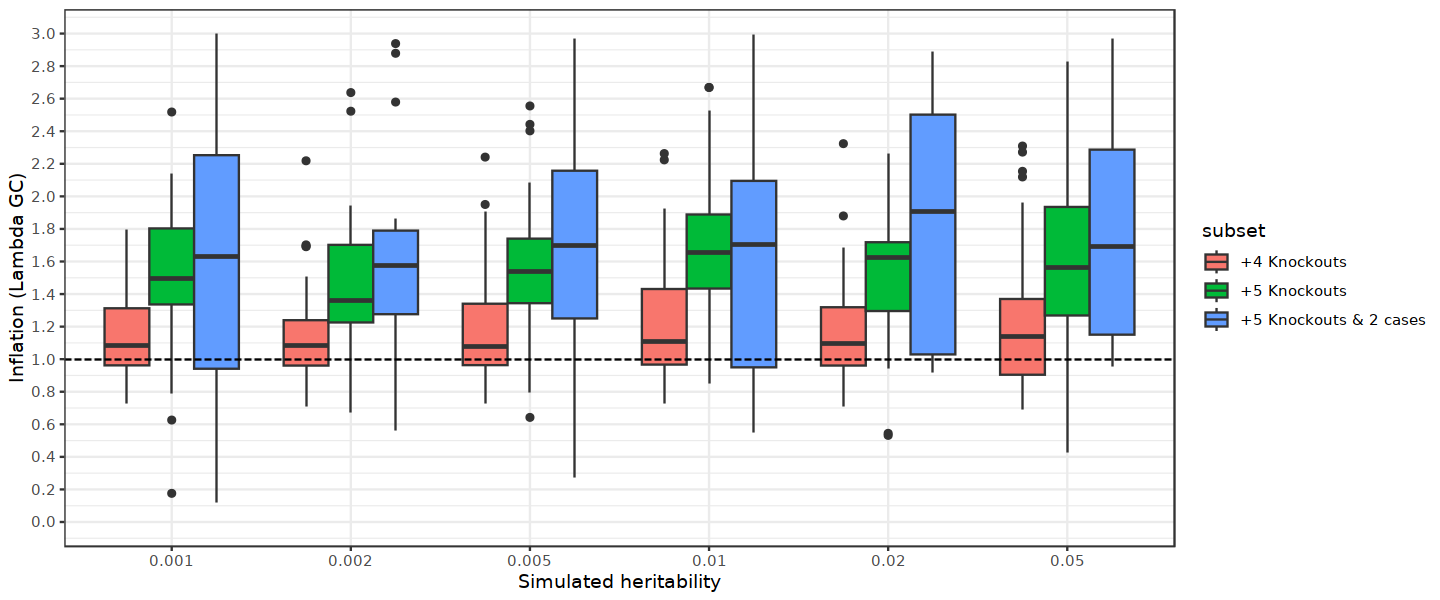

In [73]:
options(repr.plot.width=12, repr.plot.height=5)
ggplot(d_plot, aes(x=factor(h2), y=pvalue, fill = subset)) +
    geom_boxplot(position = "dodge") +
    scale_y_continuous(breaks=scales::pretty_breaks(n=15),limits = c(0,3)) +
    geom_hline(yintercept = 1, linetype = 'longdash') +
    ylab("Inflation (Lambda GC)")  +
    xlab("Simulated heritability") +
    theme_bw()

In [88]:
ggsave("derived/plots/230221_saige_rec_theta_inflation.pdf", width = 12, height = 5)

Warning message:
"Removed 225 rows containing non-finite values (`stat_boxplot()`)."


In [ ]:
heritabilities <- unique(d$h2)
d[d$h2 == 0.05]

ERROR while rich displaying an object: Error in `geom_ribbon()`:
! Problem while computing aesthetics.
i Error occurred in the 1st layer.
Caused by error in `FUN()`:
! object 'pvalue.expected' not found

Traceback:
1. FUN(X[[i]], ...)
2. tryCatch(withCallingHandlers({
 .     if (!mime %in% names(repr::mime2repr)) 
 .         stop("No repr_* for mimetype ", mime, " in repr::mime2repr")
 .     rpr <- repr::mime2repr[[mime]](obj)
 .     if (is.null(rpr)) 
 .         return(NULL)
 .     prepare_content(is.raw(rpr), rpr)
 . }, error = error_handler), error = outer_handler)
3. tryCatchList(expr, classes, parentenv, handlers)
4. tryCatchOne(expr, names, parentenv, handlers[[1L]])
5. doTryCatch(return(expr), name, parentenv, handler)
6. withCallingHandlers({
 .     if (!mime %in% names(repr::mime2repr)) 
 .         stop("No repr_* for mimetype ", mime, " in repr::mime2repr")
 .     rpr <- repr::mime2repr[[mime]](obj)
 .     if (is.null(rpr)) 
 .         return(NULL)
 .     prepare_content(is.r

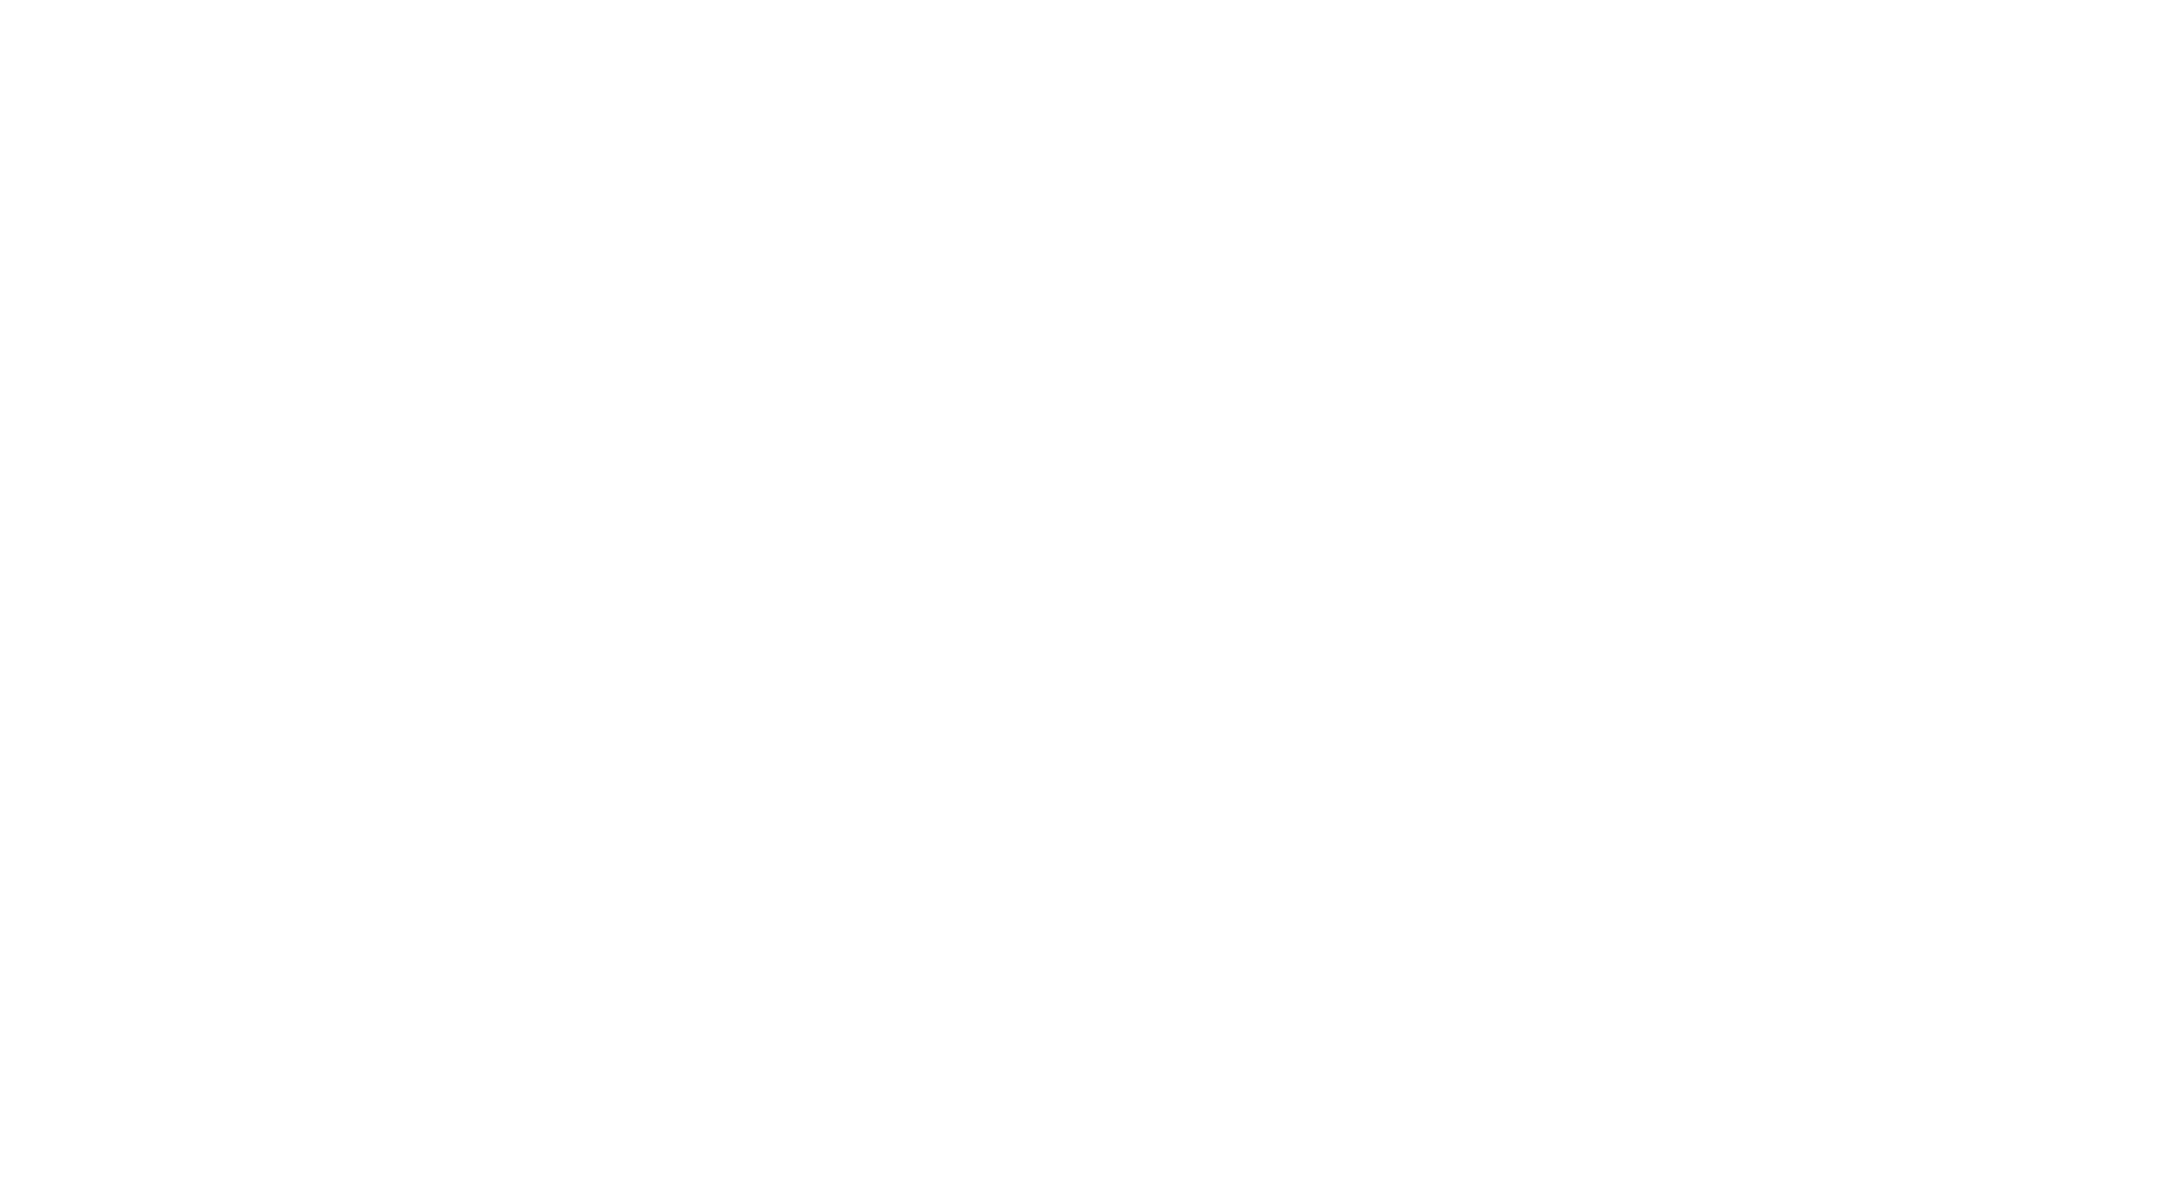

In [74]:
options(repr.plot.width=18, repr.plot.height=10)
#bonf <- 0.05 / (length(unique(d$ensembl_gene_id)) * length(unique(d$seed)))
ggplot(d_plot, aes(x=pvalue.expected, y=pvalue.observed, ymax=cupper, ymin=clower, group = fname, color = id)) +
    geom_ribbon(fill="grey80", color="black", alpha = 0.7, linetype = 'dashed') +
    #geom_line() +
    geom_point() +
    geom_abline(linetype = 'dotted') + 
    scale_x_continuous(breaks=scales::pretty_breaks(n=5)) +
    scale_y_continuous(breaks=scales::pretty_breaks(n=5)) +
    xlab(expression(paste(-log[10],'(Expected P-value)' ))) +
    ylab(expression(paste(-log[10],'(Observed P-value)' ))) +
    #geom_hline(yintercept = -log10(bonf), linetype = 'dashed', color = 'red') +
    ggtitle("Simulated phenotypes") +
    facet_wrap(~h2, scales = 'free') +
    theme_bw() +
    theme(
        axis.text=element_text(size=14),
        axis.title=element_text(size=14,face="bold"),
        axis.title.x = element_text(margin=ggplot2::margin(t=16)),
        axis.title.y = element_text(margin=ggplot2::margin(r=16)),
        plot.title = element_text(hjust=0.5),
        plot.subtitle = element_text(hjust=0.5),
            strip.text = element_text(size=16),
        legend.position="right"
    )

In [76]:
combined[(combined$h2 == 0.05) & (combined$id == 3), ]

ensembl_gene_id,theta,beta,pvalue.observed,N,seed,h2,analysis,id
<chr>,<dbl>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<chr>,<dbl>
ENSG00000075275,0.0000,0.000000,0.60743670,13,106,0.05,ukb_wes_union_calls_h2_0.05_var_0.10_99.0_pi_0.20_0.20_K0.1_seed106_chr22_case_3.txt,3
ENSG00000099937,0.0000,0.000000,0.18937532,2,106,0.05,ukb_wes_union_calls_h2_0.05_var_0.10_99.0_pi_0.20_0.20_K0.1_seed106_chr22_case_3.txt,3
ENSG00000099957,0.0000,0.000000,0.23665438,3,106,0.05,ukb_wes_union_calls_h2_0.05_var_0.10_99.0_pi_0.20_0.20_K0.1_seed106_chr22_case_3.txt,3
ENSG00000100012,1.3345,0.000000,42.24140244,43,106,0.05,ukb_wes_union_calls_h2_0.05_var_0.10_99.0_pi_0.20_0.20_K0.1_seed106_chr22_case_3.txt,3
ENSG00000100024,0.0000,0.000000,1.29247232,2,106,0.05,ukb_wes_union_calls_h2_0.05_var_0.10_99.0_pi_0.20_0.20_K0.1_seed106_chr22_case_3.txt,3
ENSG00000100068,0.0000,0.000000,0.94086958,35,106,0.05,ukb_wes_union_calls_h2_0.05_var_0.10_99.0_pi_0.20_0.20_K0.1_seed106_chr22_case_3.txt,3
ENSG00000100078,0.0000,0.000000,0.37094818,6,106,0.05,ukb_wes_union_calls_h2_0.05_var_0.10_99.0_pi_0.20_0.20_K0.1_seed106_chr22_case_3.txt,3
ENSG00000100116,0.0000,0.000000,0.01206931,11,106,0.05,ukb_wes_union_calls_h2_0.05_var_0.10_99.0_pi_0.20_0.20_K0.1_seed106_chr22_case_3.txt,3
ENSG00000100154,0.0000,0.000000,0.01987209,31,106,0.05,ukb_wes_union_calls_h2_0.05_var_0.10_99.0_pi_0.20_0.20_K0.1_seed106_chr22_case_3.txt,3


In [74]:
d_plot[(d_plot$h2 == 0.05) & (d_plot$id == 3), ]

ensembl_gene_id,pvalue.observed,pvalue.expected,clower,cupper,h2,seed,pi_1,pi_2,var_1,var_2,fname,label,fentry,id
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<fct>,<chr>,<fct>
ENSG00000100012,42.24140244,1.51851394,3.10189567,0.9630472582,0.05,106,0.2,0.2,0.1,99,ukb_wes_union_calls_h2_0.05_var_0.10_99.0_pi_0.20_0.20_K0.1_seed106_chr22_case_3.txt,NA,data/simulation/phenotypes/ukb_wes_union_calls_h2_0.05_var_0.10_99.0_pi_0.20_0.20_K0.1_seed106_chr22_3_entries.tsv.gz,3
ENSG00000176177,7.89827732,1.21748394,2.11572948,0.7900268209,0.05,106,0.2,0.2,0.1,99,ukb_wes_union_calls_h2_0.05_var_0.10_99.0_pi_0.20_0.20_K0.1_seed106_chr22_case_3.txt,NA,data/simulation/phenotypes/ukb_wes_union_calls_h2_0.05_var_0.10_99.0_pi_0.20_0.20_K0.1_seed106_chr22_3_entries.tsv.gz,3
ENSG00000198951,3.04964167,1.04139269,1.70405528,0.6817917228,0.05,106,0.2,0.2,0.1,99,ukb_wes_union_calls_h2_0.05_var_0.10_99.0_pi_0.20_0.20_K0.1_seed106_chr22_case_3.txt,NA,data/simulation/phenotypes/ukb_wes_union_calls_h2_0.05_var_0.10_99.0_pi_0.20_0.20_K0.1_seed106_chr22_3_entries.tsv.gz,3
ENSG00000100429,2.44830560,0.91645395,1.45431378,0.6016659165,0.05,106,0.2,0.2,0.1,99,ukb_wes_union_calls_h2_0.05_var_0.10_99.0_pi_0.20_0.20_K0.1_seed106_chr22_case_3.txt,NA,data/simulation/phenotypes/ukb_wes_union_calls_h2_0.05_var_0.10_99.0_pi_0.20_0.20_K0.1_seed106_chr22_3_entries.tsv.gz,3
ENSG00000100285,2.44135238,0.81954394,1.27777289,0.5376792532,0.05,106,0.2,0.2,0.1,99,ukb_wes_union_calls_h2_0.05_var_0.10_99.0_pi_0.20_0.20_K0.1_seed106_chr22_case_3.txt,NA,data/simulation/phenotypes/ukb_wes_union_calls_h2_0.05_var_0.10_99.0_pi_0.20_0.20_K0.1_seed106_chr22_3_entries.tsv.gz,3
ENSG00000186976,2.36026675,0.74036269,1.14220833,0.4842867085,0.05,106,0.2,0.2,0.1,99,ukb_wes_union_calls_h2_0.05_var_0.10_99.0_pi_0.20_0.20_K0.1_seed106_chr22_case_3.txt,NA,data/simulation/phenotypes/ukb_wes_union_calls_h2_0.05_var_0.10_99.0_pi_0.20_0.20_K0.1_seed106_chr22_3_entries.tsv.gz,3
ENSG00000100228,2.33505826,0.67341590,1.03258527,0.4384307970,0.05,106,0.2,0.2,0.1,99,ukb_wes_union_calls_h2_0.05_var_0.10_99.0_pi_0.20_0.20_K0.1_seed106_chr22_case_3.txt,NA,data/simulation/phenotypes/ukb_wes_union_calls_h2_0.05_var_0.10_99.0_pi_0.20_0.20_K0.1_seed106_chr22_3_entries.tsv.gz,3
ENSG00000175329,2.32573130,0.61542395,0.94075473,0.3982351429,0.05,106,0.2,0.2,0.1,99,ukb_wes_union_calls_h2_0.05_var_0.10_99.0_pi_0.20_0.20_K0.1_seed106_chr22_case_3.txt,NA,data/simulation/phenotypes/ukb_wes_union_calls_h2_0.05_var_0.10_99.0_pi_0.20_0.20_K0.1_seed106_chr22_3_entries.tsv.gz,3
ENSG00000100024,1.29247232,0.56427143,0.86183344,0.3624608649,0.05,106,0.2,0.2,0.1,99,ukb_wes_union_calls_h2_0.05_var_0.10_99.0_pi_0.20_0.20_K0.1_seed106_chr22_case_3.txt,NA,data/simulation/phenotypes/ukb_wes_union_calls_h2_0.05_var_0.10_99.0_pi_0.20_0.20_K0.1_seed106_chr22_3_entries.tsv.gz,3


In [ ]:
2+2

In [60]:
head(d)

locus,alleles,rsid,beta,theta,s,y_no_noise_add,y_no_noise_rec,y_no_noise,y_no_noise_rescaled,y_noise,y,case,pKO,knockout
<chr>,<chr>,<chr>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>,<dbl>,<chr>
chr22:15,"[""ujjf"",""yyXR""]",ENSG00000073169,0,0,1000028,0.038401,0,0.038401,0.008591,0.21602,0.22461,FALSE,0,NA
chr22:15,"[""ujjf"",""yyXR""]",ENSG00000073169,0,0,1000034,0.038401,0,0.038401,0.008591,0.50362,0.51221,FALSE,0,NA
chr22:15,"[""ujjf"",""yyXR""]",ENSG00000073169,0,0,1000087,0.038401,0,0.038401,0.008591,-0.39552,-0.38693,FALSE,0,NA
chr22:15,"[""ujjf"",""yyXR""]",ENSG00000073169,0,0,1000162,0.038401,0,0.038401,0.008591,-0.25562,-0.24702,FALSE,0,NA
chr22:15,"[""ujjf"",""yyXR""]",ENSG00000073169,0,0,1000171,0.038401,0,0.038401,0.008591,-0.58175,-0.57316,FALSE,0,NA
chr22:15,"[""ujjf"",""yyXR""]",ENSG00000073169,0,0,1000196,0.038401,0,0.038401,0.008591,-0.30796,-0.29937,FALSE,0,NA


In [61]:
var(d$y_no_noise_add)
var(d$y_no_noise_rec)

[1] 0.09720552

[1] 0.002476797

In [52]:
var(d$y_no_noise_rescaled)

[1] 0.0050008

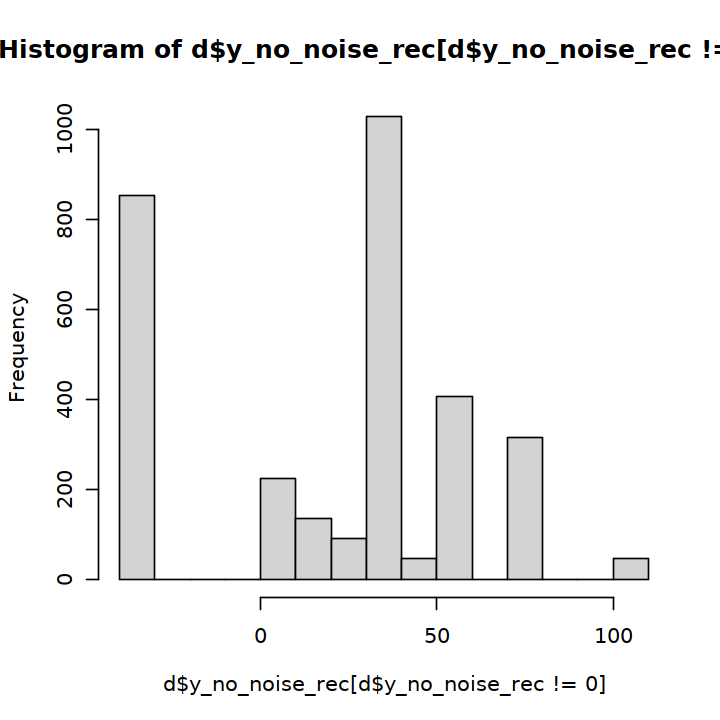

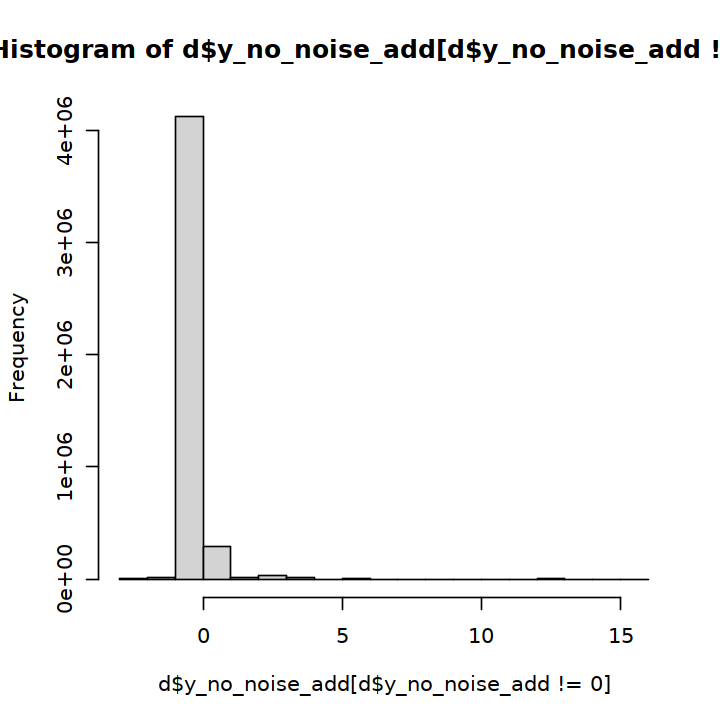

In [53]:
options(repr.plot.width=6, repr.plot.height=6)
hist(d$y_no_noise_rec[d$y_no_noise_rec != 0]);
hist(d$y_no_noise_add[d$y_no_noise_add != 0]);

In [ ]:
fread("data/")